# SmartGrid Demo Globale

Notebook unique pour la demonstration end-to-end du projet :
- benchmark global des configurations ;
- promotion du modele retenu ;
- prediction jour suivant ;
- replay multi-jours ;
- analyse detaillee du run retenu ;
- comparaison replay vs baseline et autres modeles.


In [12]:
from __future__ import annotations

from pathlib import Path
import json
import os
import shlex
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 220)
pd.set_option('display.float_format', lambda x: f'{x:,.6f}')
plt.style.use('seaborn-v0_8')

METRIC_COLUMNS = [
    'MAE', 'RMSE', 'Bias(ME)', 'MAPE%', 'SMAPE%', 'InTolerance%',
    'P95AbsError', 'P99AbsError', 'UnderShare%', 'OverShare%',
    'Under_MAE', 'Over_MAE', 'CorrAbsErr_vs_Real', 'RampingError_RMSE'
]
BASELINE_SKILL_METRICS = ['MAE', 'RMSE', 'MAPE%', 'SMAPE%', 'RampingError_RMSE']


## 1. Configuration

Les interrupteurs ci-dessous permettent soit de lancer toute la demo depuis zero,
soit de reutiliser des artefacts deja produits.


In [13]:
MANUAL_PROJECT_ROOT = None

DATASET_KEY = "full_2020_2026"
DATASET_OVERRIDES = {
    'historical_csv': None,
    'forecast_csv': None,
    'benchmark_csv': None,
    'weather_csv': None,
    'holidays_xlsx': None,
}

# ============================================================================
# Bloc a modifier pour un usage normal du notebook
# ============================================================================
ANALYSIS_WINDOW_START_DATE = '2025-11-01'
ANALYSIS_WINDOW_END_DATE = '2025-11-30'
ANALYSIS_FOCUS_DATE = None   # None => prend automatiquement le dernier jour de la fenetre.
ANALYSIS_SORT_METRIC = 'MAE'

COMPARE_RUN_IDS = [
    'consumption_mlp_20260416T115420Z',  # strict baseline
    'consumption_mlp_20260416T115631Z',  # strict weather basic
    'consumption_mlp_20260416T115812Z',  # strict cyclical + weather basic
    'consumption_mlp_20260416T115937Z',  # strict cyclical + weather + shifted dynamics
]   # [] => laisse le notebook choisir automatiquement les candidats replay.
FOCUS_RUN_ID = None   # None => replay winner / current / meilleur benchmark disponible.
SAME_DAY_COMPARISON_RUN_ID = None   # None => reutilise automatiquement le focus run.
USE_REPLAY_WINNER_FOR_FOCUS = True

# ============================================================================
# Options avancees
# ============================================================================
RUN_REPLAY_BENCHMARK = True
REPLAY_REQUIRE_FRESH_RUNS = False
REPLAY_CONFIGS = [
    'configs/consumption/mlp_baseline.yaml',
    'configs/consumption/mlp_strict_day_ahead_baseline.yaml',
    'configs/consumption/mlp_strict_day_ahead_weather_basic.yaml',
    'configs/consumption/mlp_strict_day_ahead_cyclical_weather_basic.yaml',
    'configs/consumption/mlp_strict_day_ahead_cyclical_weather_shifted_dynamics.yaml',
]
TOP_N_REPLAY_OTHER_MODELS = 3
PROMOTE_REPLAY_WINNER = False
PROMOTE_REPLAY_METRIC = 'MAE'
MANUAL_REPLAY_SUMMARY_CSV = None
MANUAL_REPLAY_MANIFEST_JSON = None

RUN_TRAINING_BENCHMARK = False
TRAIN_CONFIGS = [
    'configs/consumption/mlp_baseline.yaml',
    'configs/consumption/mlp_strict_day_ahead_baseline.yaml',
    'configs/consumption/mlp_strict_day_ahead_weather_basic.yaml',
    'configs/consumption/mlp_strict_day_ahead_cyclical_weather_basic.yaml',
    'configs/consumption/mlp_strict_day_ahead_cyclical_weather_shifted_dynamics.yaml',
    'configs/consumption/mlp_cyclical_weather_dynamics.yaml',
    'configs/consumption/mlp_cyclical_weather_dynamics_all.yaml',
]
TRAIN_ANALYSIS_DAYS = 1
TRAIN_ANALYSIS_DATE = None   # Override avance. None => utilise ANALYSIS_FOCUS_DATE.
TRAIN_PROMOTE_IMMEDIATELY = False
BENCHMARK_OUTPUT_CSV = 'artifacts/benchmarks/demo_consumption_feature_variants.csv'
MANUAL_BENCHMARK_CSV = None
AUTO_BOOTSTRAP_IF_EMPTY = False
BOOTSTRAP_TRAIN_CONFIGS = list(TRAIN_CONFIGS)

PROMOTE_SELECTED_RUN = False
PROMOTE_RUN_ID = None
PROMOTE_STRATEGY = 'best_mae'   # 'best_rmse' | 'best_mae' | 'current'

RUN_NEXT_DAY_FORECAST = False
FORECAST_TARGET_DATE = None   # Override avance. None => utilise ANALYSIS_FOCUS_DATE.
FORECAST_OUTPUT_CSV = None
FORECAST_ALLOW_FALLBACK = False

# Alias de compatibilite interne: en general, ne pas modifier manuellement.
REPLAY_START_DATE = ANALYSIS_WINDOW_START_DATE
REPLAY_END_DATE = ANALYSIS_WINDOW_END_DATE
PROTOCOL_COMPARISON_DATE = ANALYSIS_FOCUS_DATE
PROTOCOL_COMPARISON_RUN_ID = SAME_DAY_COMPARISON_RUN_ID
REPLAY_MODEL_RUN_IDS = list(COMPARE_RUN_IDS)
DETAILED_RUN_ID = FOCUS_RUN_ID
USE_REPLAY_WINNER_FOR_DETAILED_ANALYSIS = USE_REPLAY_WINNER_FOR_FOCUS
PREFERRED_SORT_METRIC = ANALYSIS_SORT_METRIC
REPLAY_SORT_METRIC = ANALYSIS_SORT_METRIC
DETAILED_ANALYSIS_DATE = None
PLOT_LAST_N_POINTS = 7 * 144


## 2. Helpers


In [14]:
def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start] + list(start.parents):
        if (candidate / 'pyproject.toml').exists() and (candidate / 'src' / 'smartgrid').exists():
            return candidate
    raise FileNotFoundError('Impossible de trouver la racine du projet.')


def ensure_project_on_path(project_root: Path) -> None:
    src_dir = project_root / 'src'
    if str(src_dir) not in sys.path:
        sys.path.insert(0, str(src_dir))


def first_existing(paths) -> Path | None:
    for path in paths:
        if path and Path(path).exists():
            return Path(path)
    return None


def resolve_existing_path(path_like, *bases: Path) -> Path | None:
    if not path_like:
        return None
    raw = Path(path_like).expanduser()
    candidates = [raw]
    if not raw.is_absolute():
        for base in bases:
            if base is not None:
                candidates.append(base / raw)
    return first_existing(candidates)


def resolve_path(path_like, project_root: Path) -> Path | None:
    return resolve_existing_path(path_like, project_root)


def choose_first_col(df: pd.DataFrame, candidates: list[str], required: bool = True) -> str | None:
    for col in candidates:
        if col in df.columns:
            return col
    if required:
        raise KeyError(f'Aucune colonne trouvee parmi {candidates}. Colonnes: {list(df.columns)}')
    return None


def load_json(path: str | Path) -> dict:
    return json.loads(Path(path).read_text(encoding='utf-8'))


def normalize_date_str(value: str | None) -> str | None:
    if value is None:
        return None
    text = str(value).strip()
    if not text or text.lower() == 'none':
        return None
    return str(pd.Timestamp(text).date())


def resolve_analysis_focus_date(
    focus_date: str | None,
    *,
    window_start: str | None = None,
    window_end: str | None = None,
) -> str | None:
    start = normalize_date_str(window_start)
    end = normalize_date_str(window_end)
    resolved = normalize_date_str(focus_date)

    if start is not None and end is not None and pd.Timestamp(start) > pd.Timestamp(end):
        raise ValueError(f'Fenetre d\'analyse invalide: start_date={start} > end_date={end}')

    if resolved is None:
        resolved = end or start

    if resolved is not None and start is not None and pd.Timestamp(resolved) < pd.Timestamp(start):
        raise ValueError(f'Le focus date {resolved} est avant le debut de fenetre {start}.')
    if resolved is not None and end is not None and pd.Timestamp(resolved) > pd.Timestamp(end):
        raise ValueError(f'Le focus date {resolved} est apres la fin de fenetre {end}.')
    return resolved


def sync_protocol_comparison_config() -> str | None:
    global TRAIN_ANALYSIS_DATE, DETAILED_ANALYSIS_DATE, FORECAST_TARGET_DATE
    comparison_date = resolve_analysis_focus_date(
        PROTOCOL_COMPARISON_DATE,
        window_start=REPLAY_START_DATE,
        window_end=REPLAY_END_DATE,
    )
    if TRAIN_ANALYSIS_DATE is None:
        TRAIN_ANALYSIS_DATE = comparison_date
    if DETAILED_ANALYSIS_DATE is None:
        DETAILED_ANALYSIS_DATE = comparison_date
    if FORECAST_TARGET_DATE is None:
        FORECAST_TARGET_DATE = comparison_date
    return comparison_date


def resolve_notebook_data_config(project_root: Path) -> dict:
    from smartgrid.data.catalog import resolve_consumption_data_config

    base_cfg = {'dataset_key': DATASET_KEY} if DATASET_KEY else {}
    return resolve_consumption_data_config(
        base_cfg,
        project_root=project_root,
        overrides=dict(DATASET_OVERRIDES or {}),
    )


def resolve_notebook_data_paths(project_root: Path) -> tuple[Path | None, Path | None, Path | None, Path | None]:
    data_cfg = resolve_notebook_data_config(project_root)
    historical_csv = resolve_existing_path(data_cfg.get('historical_csv'), project_root)
    benchmark_csv = resolve_existing_path(data_cfg.get('benchmark_csv') or data_cfg.get('forecast_csv'), project_root)
    weather_csv = resolve_existing_path(data_cfg.get('weather_csv'), project_root)
    holidays_xlsx = resolve_existing_path(data_cfg.get('holidays_xlsx'), project_root)
    return historical_csv, benchmark_csv, weather_csv, holidays_xlsx


def run_command(command: list[str], project_root: Path) -> str:
    env = os.environ.copy()
    env['PYTHONPATH'] = str(project_root / 'src') + (os.pathsep + env['PYTHONPATH'] if env.get('PYTHONPATH') else '')
    print('> ' + ' '.join(shlex.quote(part) for part in command))
    completed = subprocess.run(command, cwd=project_root, env=env, capture_output=True, text=True)
    if completed.stdout.strip():
        print(completed.stdout)
    if completed.returncode != 0:
        if completed.stderr.strip():
            print(completed.stderr)
        raise RuntimeError(f'Commande en echec code={completed.returncode}')
    return completed.stdout


def extract_last_json(stdout: str) -> dict:
    decoder = json.JSONDecoder()
    starts = [index for index, char in enumerate(stdout) if char == '{']
    for start in reversed(starts):
        snippet = stdout[start:]
        try:
            payload, end = decoder.raw_decode(snippet)
            if snippet[end:].strip() == '':
                return payload
        except json.JSONDecodeError:
            continue
    raise RuntimeError('Impossible de retrouver le JSON final dans la sortie de commande.')


def find_benchmark_csv(project_root: Path) -> Path | None:
    if MANUAL_BENCHMARK_CSV:
        path = Path(MANUAL_BENCHMARK_CSV)
        if path.exists():
            return path.resolve()
        raise FileNotFoundError(f'Benchmark CSV introuvable: {path}')
    candidates = [
        project_root / 'artifacts' / 'benchmarks' / 'consumption_feature_variants.csv',
        project_root / 'artifacts' / 'benchmarks' / 'feature_variants.csv',
        project_root / BENCHMARK_OUTPUT_CSV,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    found = sorted((project_root / 'artifacts').glob('**/*feature*variant*.csv'))
    if found:
        return found[-1].resolve()
    return None


def find_latest_replay_benchmark(project_root: Path) -> tuple[Path, Path | None] | tuple[None, None]:
    base = project_root / 'artifacts' / 'benchmarks' / 'replay'
    if not base.exists():
        return None, None
    candidates = sorted(path for path in base.iterdir() if path.is_dir())
    if not candidates:
        return None, None
    latest = candidates[-1]
    summary_csv = latest / 'replay_benchmark_summary.csv'
    manifest_json = latest / 'replay_benchmark_manifest.json'
    return summary_csv.resolve(), manifest_json.resolve() if manifest_json.exists() else None


def find_history_csv(project_root: Path) -> Path | None:
    historical_csv, _, _, _ = resolve_notebook_data_paths(project_root)
    return historical_csv

def list_available_train_configs(project_root: Path) -> list[str]:
    config_dir = project_root / 'configs' / 'consumption'
    return [str(path.relative_to(project_root)) for path in sorted(config_dir.glob('*.yaml'))]


def format_feature_signature(feature_cfg: dict | None) -> str:
    feature_cfg = dict(feature_cfg or {})
    parts = []
    if feature_cfg.get('include_calendar', True):
        parts.append('cal')
    if feature_cfg.get('include_temperature', False):
        parts.append('temp')
    if feature_cfg.get('include_manual_daily_lags', False):
        parts.append('lags')
    if feature_cfg.get('include_cyclical_time', False):
        parts.append('cyc')
    if feature_cfg.get('include_lag_aggregates', False):
        parts.append('lagagg')
    if feature_cfg.get('include_recent_dynamics', False):
        parts.append('dyn')
    if feature_cfg.get('include_weather', False):
        parts.append(f"weather={feature_cfg.get('weather_mode', 'custom')}")
    if not feature_cfg.get('include_temperature', False) and not feature_cfg.get('include_weather', False):
        parts.append('no-weather')
    lag_days = feature_cfg.get('lag_days') or []
    if lag_days:
        parts.append('J=' + '-'.join(str(day) for day in lag_days))
    return ' | '.join(parts) if parts else 'features inconnues'


def collect_runs(project_root: Path) -> pd.DataFrame:
    rows = []
    runs_dir = project_root / 'artifacts' / 'runs' / 'consumption'
    for run_summary_path in sorted(runs_dir.glob('*/run_summary.json')):
        payload = load_json(run_summary_path)
        config_path = payload.get('config_path')
        config_name = Path(config_path).name if config_path else None
        feature_config = payload.get('feature_config') or {}
        rows.append({
            'run_id': str(payload.get('run_id', run_summary_path.parent.name)),
            'run_summary_path': str(run_summary_path.resolve()),
            'run_dir': str(run_summary_path.parent.resolve()),
            'exports_dir': payload.get('exports_dir'),
            'config_path': config_path,
            'config_name': config_name,
            'experiment_name': payload.get('experiment_name'),
            'feature_config': feature_config,
            'forecast_mode': payload.get('forecast_mode') or feature_config.get('forecast_mode'),
            'feature_columns': payload.get('feature_columns') or [],
            'hidden_layers': payload.get('hidden_layers') or [],
            'n_features': payload.get('n_features'),
            'historical_csv': payload.get('historical_csv'),
            'weather_csv': payload.get('weather_csv'),
            'holidays_xlsx': payload.get('holidays_xlsx'),
        })
    catalog_df = pd.DataFrame(rows)
    if catalog_df.empty:
        return catalog_df
    catalog_df['feature_signature'] = catalog_df['feature_config'].map(format_feature_signature)
    catalog_df['arch_label'] = catalog_df['hidden_layers'].map(lambda value: f'MLP {value}' if isinstance(value, list) and value else 'MLP')
    catalog_df['short_name'] = catalog_df.apply(
        lambda row: Path(row['config_name']).stem if pd.notna(row.get('config_name')) and row.get('config_name') else (row.get('experiment_name') or row['run_id']),
        axis=1,
    )
    catalog_df['display_name'] = catalog_df['short_name'] + ' | ' + catalog_df['feature_signature']
    catalog_df['is_baseline_config'] = catalog_df['config_name'].fillna('').str.contains('baseline', case=False, na=False)
    return catalog_df


def current_run_id(project_root: Path) -> str | None:
    summary_path = project_root / 'artifacts' / 'models' / 'consumption' / 'current' / 'run_summary.json'
    if not summary_path.exists():
        return None
    run_id = str(load_json(summary_path).get('run_id', '')).strip()
    return run_id or None


def payloads_to_benchmark_df(payloads: list[dict]) -> pd.DataFrame:
    rows = []
    for payload in payloads:
        metrics = dict(payload.get('metrics_model') or {})
        rows.append({
            'config_name': payload.get('config'),
            'run_id': payload.get('run_id'),
            'run_dir': payload.get('run_dir'),
            'exports_dir': payload.get('exports_dir'),
            'experiment_name': payload.get('experiment_name'),
            'selected_analysis_day': payload.get('selected_analysis_day'),
            'train_duration_sec': payload.get('train_duration_sec'),
            'n_features': payload.get('n_features'),
            'epochs_ran': payload.get('epochs_ran'),
            'best_val_loss': payload.get('best_val_loss'),
            'final_train_loss': payload.get('final_train_loss'),
            'final_val_loss': payload.get('final_val_loss'),
            'n_train_rows': payload.get('n_train_rows'),
            'n_val_rows': payload.get('n_val_rows'),
            'n_test_rows': payload.get('n_test_rows'),
            'forecast_mode': payload.get('forecast_mode'),
            'feature_config_json': json.dumps(payload.get('feature_config'), sort_keys=True),
            **metrics,
        })
    return pd.DataFrame(rows)


def build_benchmark_df_from_catalog(catalog_df: pd.DataFrame) -> pd.DataFrame:
    if catalog_df.empty:
        return pd.DataFrame()
    rows = []
    for _, row in catalog_df.iterrows():
        payload = load_json(row['run_summary_path'])
        metrics = dict(payload.get('metrics_model') or {})
        config_path = payload.get('config_path')
        rows.append({
            'config_name': Path(str(config_path)).name if config_path else row.get('config_name'),
            'run_id': payload.get('run_id') or row.get('run_id'),
            'run_dir': payload.get('run_dir') or row.get('run_dir'),
            'exports_dir': payload.get('exports_dir') or row.get('exports_dir'),
            'experiment_name': payload.get('experiment_name') or row.get('experiment_name'),
            'selected_analysis_day': payload.get('selected_analysis_day'),
            'train_duration_sec': payload.get('train_duration_sec'),
            'n_features': payload.get('n_features'),
            'epochs_ran': payload.get('epochs_ran'),
            'best_val_loss': payload.get('best_val_loss'),
            'final_train_loss': payload.get('final_train_loss'),
            'final_val_loss': payload.get('final_val_loss'),
            'n_train_rows': payload.get('n_train_rows'),
            'n_val_rows': payload.get('n_val_rows'),
            'n_test_rows': payload.get('n_test_rows'),
            'forecast_mode': payload.get('forecast_mode'),
            'feature_config_json': json.dumps(payload.get('feature_config'), sort_keys=True),
            **metrics,
        })
    return pd.DataFrame(rows)


def resolve_bootstrap_train_configs(project_root: Path) -> list[str]:
    raw_configs = BOOTSTRAP_TRAIN_CONFIGS or TRAIN_CONFIGS
    if not raw_configs:
        return list_available_train_configs(project_root)
    resolved = []
    for config_path in raw_configs:
        path = resolve_existing_path(config_path, project_root) or Path(config_path)
        if isinstance(path, Path) and path.is_absolute():
            try:
                resolved.append(str(path.relative_to(project_root)))
            except ValueError:
                resolved.append(str(path))
        else:
            resolved.append(str(path))
    return resolved


def normalize_benchmark_df(bench: pd.DataFrame, catalog_df: pd.DataFrame) -> pd.DataFrame:
    if bench.empty:
        return bench.copy()
    out = bench.copy()
    out.columns = [str(col).strip() for col in out.columns]
    if 'config' in out.columns and 'config_name' not in out.columns:
        out = out.rename(columns={'config': 'config_name'})
    if 'run_id' not in out.columns:
        raise KeyError('Le benchmark doit contenir une colonne run_id.')
    meta = catalog_df.rename(columns={'run_id': 'run_id_meta'}).copy() if not catalog_df.empty else pd.DataFrame()
    if not meta.empty:
        meta = meta.rename(columns={'run_id_meta': 'run_id'})
        keep_cols = [
            'run_id', 'run_summary_path', 'run_dir', 'exports_dir', 'config_path', 'config_name',
            'experiment_name', 'feature_config', 'feature_columns', 'hidden_layers', 'n_features',
            'historical_csv', 'weather_csv', 'holidays_xlsx', 'forecast_mode', 'feature_signature', 'arch_label',
            'short_name', 'display_name', 'is_baseline_config'
        ]
        keep_cols = [col for col in keep_cols if col in meta.columns]
        out = out.merge(meta[keep_cols], on='run_id', how='left', suffixes=('', '_meta'))
        if 'config_name_meta' in out.columns:
            out['config_name'] = out['config_name'].fillna(out['config_name_meta'])
            out = out.drop(columns=['config_name_meta'])
        if 'experiment_name_meta' in out.columns:
            out['experiment_name'] = out['experiment_name'].fillna(out['experiment_name_meta'])
            out = out.drop(columns=['experiment_name_meta'])
        for col in ['run_dir', 'exports_dir', 'n_features']:
            meta_col = f'{col}_meta'
            if meta_col in out.columns:
                out[col] = out[col].fillna(out[meta_col]) if col in out.columns else out[meta_col]
                out = out.drop(columns=[meta_col])
    if 'config_name' in out.columns:
        out['config_stem'] = out['config_name'].map(lambda value: Path(str(value)).stem if pd.notna(value) else None)
    else:
        out['config_stem'] = out['run_id']
    if 'display_name' not in out.columns:
        out['display_name'] = out['config_stem']
    for metric in METRIC_COLUMNS + ['count']:
        if metric in out.columns:
            out[metric] = pd.to_numeric(out[metric], errors='coerce')
    return out


def add_baseline_comparison(df: pd.DataFrame, baseline_run_id: str | None) -> pd.DataFrame:
    out = df.copy()
    for metric in BASELINE_SKILL_METRICS:
        if metric in out.columns:
            out[f'{metric}_delta_vs_baseline'] = np.nan
            out[f'{metric}_skill_vs_baseline_%'] = np.nan
    if 'InTolerance%' in out.columns:
        out['InTolerance_delta_vs_baseline'] = np.nan
    if not baseline_run_id or baseline_run_id not in out['run_id'].astype(str).tolist():
        return out
    baseline_row = out[out['run_id'].astype(str) == str(baseline_run_id)].iloc[0]
    for metric in BASELINE_SKILL_METRICS:
        if metric in out.columns:
            out[f'{metric}_delta_vs_baseline'] = out[metric] - baseline_row[metric]
            if baseline_row[metric] != 0 and pd.notna(baseline_row[metric]):
                out[f'{metric}_skill_vs_baseline_%'] = 100 * (1 - out[metric] / baseline_row[metric])
    if 'InTolerance%' in out.columns:
        out['InTolerance_delta_vs_baseline'] = out['InTolerance%'] - baseline_row['InTolerance%']
    return out


def resolve_baseline_run_id(bench: pd.DataFrame) -> str | None:
    if 'config_name' not in bench.columns:
        return None
    baseline_mask = bench['config_name'].astype(str).str.contains('baseline', case=False, na=False)
    if not baseline_mask.any():
        return None
    sort_cols = [col for col in [PREFERRED_SORT_METRIC, 'RMSE', 'MAE'] if col in bench.columns]
    return str(bench.loc[baseline_mask].sort_values(sort_cols or ['run_id']).iloc[0]['run_id'])


def resolve_promoted_run_id(bench: pd.DataFrame, current_id: str | None) -> str | None:
    if PROMOTE_RUN_ID:
        return str(PROMOTE_RUN_ID)
    if PROMOTE_STRATEGY == 'current':
        return current_id
    sort_metric = 'MAE' if PROMOTE_STRATEGY == 'best_mae' else 'RMSE'
    if sort_metric not in bench.columns:
        sort_metric = 'MAE' if 'MAE' in bench.columns else None
    if sort_metric is None or bench.empty:
        return current_id
    return str(bench.sort_values([sort_metric, 'MAE' if sort_metric != 'MAE' and 'MAE' in bench.columns else sort_metric], ascending=True).iloc[0]['run_id'])


def describe_train_device(project_root: Path, config_path: str) -> dict:
    from smartgrid.common.utils import get_device, load_yaml

    resolved_config_path = resolve_existing_path(config_path, project_root) or Path(config_path)
    cfg = load_yaml(resolved_config_path)
    requested_device = str((cfg or {}).get('training', {}).get('device', 'auto'))
    resolved_device = str(get_device(requested_device))
    return {
        'config_path': str(resolved_config_path),
        'config_name': Path(str(resolved_config_path)).name,
        'requested_device': requested_device,
        'resolved_device': resolved_device,
    }


def train_config(project_root: Path, config_path: str) -> dict:
    device_info = describe_train_device(project_root, config_path)
    print(f"\n[TRAIN START] {device_info['config_name']} | requested={device_info['requested_device']} | resolved={device_info['resolved_device']}")
    if device_info['resolved_device'] == 'cpu':
        print('WARNING: ce modele va etre entraine sur CPU.')

    data_cfg = resolve_notebook_data_config(project_root)
    command = [
        sys.executable,
        str(project_root / 'scripts' / 'train_consumption.py'),
        '--config', str(resolve_existing_path(config_path, project_root) or config_path),
        '--analysis-days', str(TRAIN_ANALYSIS_DAYS),
    ]
    if data_cfg.get('dataset_key'):
        command.extend(['--dataset-key', str(data_cfg['dataset_key'])])
    if data_cfg.get('catalog_path'):
        command.extend(['--catalog-path', str(data_cfg['catalog_path'])])
    for arg_name, key in [
        ('--historical-csv', 'historical_csv'),
        ('--benchmark-csv', 'benchmark_csv'),
        ('--weather-csv', 'weather_csv'),
        ('--holidays-xlsx', 'holidays_xlsx'),
    ]:
        if data_cfg.get(key):
            command.extend([arg_name, str(data_cfg[key])])
    if TRAIN_ANALYSIS_DATE:
        command.extend(['--analysis-date', str(TRAIN_ANALYSIS_DATE)])
    if TRAIN_PROMOTE_IMMEDIATELY:
        command.append('--promote')
    return extract_last_json(run_command(command, project_root))


def promote_run(project_root: Path, run_id: str) -> None:
    command = [
        sys.executable,
        str(project_root / 'scripts' / 'promote_consumption_run.py'),
        '--run-id', str(run_id),
    ]
    run_command(command, project_root)


def resolve_run_summary_path(project_root: Path, run_id: str) -> Path | None:
    candidates = [
        project_root / 'artifacts' / 'runs' / 'consumption' / str(run_id) / 'run_summary.json',
        project_root / 'artifacts' / 'exports' / 'consumption' / str(run_id) / 'run_summary.json',
        project_root / 'artifacts' / 'models' / 'consumption' / 'current' / 'run_summary.json',
    ]
    for candidate in candidates:
        if candidate.exists():
            payload = load_json(candidate)
            if str(payload.get('run_id', run_id)) == str(run_id):
                return candidate.resolve()
    return None


def resolve_run_data_inputs(project_root: Path, run_id: str) -> tuple[Path | None, Path | None, Path | None]:
    historical_csv, _, weather_csv, holidays_xlsx = resolve_notebook_data_paths(project_root)
    if historical_csv is not None:
        return historical_csv, weather_csv, holidays_xlsx

    from smartgrid.common.utils import load_yaml

    summary_path = resolve_run_summary_path(project_root, run_id)
    if summary_path is None:
        return None, None, None
    payload = load_json(summary_path)
    config_path = payload.get('config_path')
    cfg = {}
    if config_path and resolve_existing_path(config_path, project_root):
        cfg = load_yaml(resolve_existing_path(config_path, project_root)) or {}
    data_cfg = dict(cfg.get('data', {}))
    historical_csv = resolve_existing_path(payload.get('historical_csv') or data_cfg.get('historical_csv'), project_root)
    weather_csv = resolve_existing_path(payload.get('weather_csv') or data_cfg.get('weather_csv'), project_root)
    holidays_xlsx = resolve_existing_path(payload.get('holidays_xlsx') or data_cfg.get('holidays_xlsx'), project_root)
    return historical_csv, weather_csv, holidays_xlsx


def run_next_day_forecast(project_root: Path, run_id: str, target_date: str | None = None) -> dict:
    historical_csv, weather_csv, holidays_xlsx = resolve_run_data_inputs(project_root, run_id)
    if historical_csv is None:
        raise FileNotFoundError(f'Impossible de resoudre historical_csv pour le run {run_id}')
    output_csv = resolve_existing_path(FORECAST_OUTPUT_CSV, project_root) if FORECAST_OUTPUT_CSV else project_root / 'artifacts' / 'forecasts' / 'consumption' / 'demo_forecast.csv'
    command = [
        sys.executable,
        str(project_root / 'scripts' / 'predict_next_day.py'),
        '--historical-csv', str(historical_csv),
        '--current-dir', str(project_root / 'artifacts' / 'models' / 'consumption' / 'current'),
        '--artifacts-root', str(project_root / 'artifacts'),
        '--output-csv', str(output_csv),
    ]
    if target_date:
        command.extend(['--target-date', str(target_date)])
    if weather_csv is not None:
        command.extend(['--weather-csv', str(weather_csv)])
    if holidays_xlsx is not None:
        command.extend(['--holidays-xlsx', str(holidays_xlsx)])
    if FORECAST_ALLOW_FALLBACK:
        command.append('--allow-fallback')
    return extract_last_json(run_command(command, project_root))


def forecast_run_for_target_day(project_root: Path, run_id: str, target_date: str) -> pd.DataFrame:
    import importlib
    import smartgrid.features.engineering as engineering_module
    import smartgrid.inference.consumption as consumption_module
    import smartgrid.inference.day_ahead as day_ahead_module

    engineering_module = importlib.reload(engineering_module)
    consumption_module = importlib.reload(consumption_module)
    day_ahead_module = importlib.reload(day_ahead_module)
    build_forecast_runtime = day_ahead_module.build_forecast_runtime
    forecast_target_day = day_ahead_module.forecast_target_day

    artifacts = resolve_run_artifacts(project_root, run_id)
    historical_csv, weather_csv, holidays_xlsx = resolve_run_data_inputs(project_root, run_id)
    if historical_csv is None:
        raise FileNotFoundError(f'Impossible de resoudre historical_csv pour le run {run_id}')

    _, benchmark_csv, _, _ = resolve_notebook_data_paths(project_root)
    runtime = build_forecast_runtime(
        historical_csv=historical_csv,
        current_dir=artifacts['run_dir'],
        artifacts_root=project_root / 'artifacts',
        weather_csv=weather_csv,
        holidays_xlsx=holidays_xlsx,
        benchmark_csv=benchmark_csv,
        device_request='auto',
        allow_fallback=FORECAST_ALLOW_FALLBACK,
    )
    try:
        return forecast_target_day(runtime, str(pd.Timestamp(target_date).date()))
    except RuntimeError as exc:
        raise RuntimeError(
            f'Echec de reconstruction du jour cible {target_date} pour le run {run_id}. '
            f'Redemarre le kernel puis relance le notebook depuis le debut si le code a change. '\
            f'Detail: {exc}'
        ) from exc


def build_requested_day_frame(project_root: Path, run_id: str, target_date: str, history_csv: Path | None = None) -> pd.DataFrame:
    from smartgrid.data.loaders import load_old_benchmark

    target_date = str(pd.Timestamp(target_date).date())
    forecast_df = forecast_run_for_target_day(project_root, run_id, target_date)
    if forecast_df.empty:
        return pd.DataFrame()

    day_df = forecast_df.rename(columns={'Ptot_TOTAL_Forecast': 'MODEL', 'Ptot_TOTAL_Real': 'REAL'}).copy()
    day_df['Date'] = pd.to_datetime(day_df['Date'], errors='coerce')
    day_df = day_df.dropna(subset=['Date']).sort_values('Date').reset_index(drop=True)

    if history_csv is not None:
        hist_total = load_history_total(history_csv)
        day_df['BASELINE_WEEKLY'] = compute_weekly_naive_for_dates(day_df['Date'], hist_total)

    _, benchmark_csv, _, _ = resolve_notebook_data_paths(project_root)
    old_legacy_df = load_old_benchmark(benchmark_csv) if benchmark_csv is not None else None
    if old_legacy_df is not None and not old_legacy_df.empty:
        old_legacy_df = old_legacy_df.rename(columns={'OldLegacy_TOTAL_Forecast': 'OLD_LEGACY'})
        old_legacy_df['Date'] = pd.to_datetime(old_legacy_df['Date'], errors='coerce')
        old_legacy_df = old_legacy_df[old_legacy_df['Date'].dt.date == pd.to_datetime(target_date).date()]
        day_df = day_df.merge(old_legacy_df[['Date', 'OLD_LEGACY']].drop_duplicates(subset=['Date']), on='Date', how='left')

    keep_cols = [col for col in ['Date', 'REAL', 'MODEL', 'BASELINE_WEEKLY', 'OLD_LEGACY', 'model_run_id', 'target_date'] if col in day_df.columns]
    return day_df[keep_cols].copy()


def resolve_run_artifacts(project_root: Path, run_id: str) -> dict:
    summary_path = resolve_run_summary_path(project_root, run_id)
    if summary_path is None:
        raise FileNotFoundError(f'run_summary introuvable pour {run_id}')
    summary = load_json(summary_path)
    run_dir = resolve_existing_path(summary.get('run_dir'), project_root, summary_path.parent) or summary_path.parent
    exports_dir = first_existing([
        resolve_existing_path(summary.get('exports_dir'), project_root, run_dir, summary_path.parent),
        project_root / 'artifacts' / 'exports' / 'consumption' / str(run_id),
        summary_path.parent,
    ])
    backtest_csv = first_existing([
        resolve_existing_path(summary.get('backtest_csv'), project_root, run_dir, exports_dir, summary_path.parent),
        run_dir / 'backtest.csv',
        exports_dir / 'backtest.csv' if exports_dir else None,
    ])
    day_csv = first_existing([
        resolve_existing_path(summary.get('day_compare_csv'), project_root, run_dir, exports_dir, summary_path.parent),
        run_dir / f"selected_day_{summary.get('selected_analysis_day', '')}.csv",
        exports_dir / f"selected_day_{summary.get('selected_analysis_day', '')}.csv" if exports_dir else None,
    ])
    total_csv = first_existing([
        resolve_existing_path(summary.get('output_total_csv'), project_root, run_dir, exports_dir, summary_path.parent),
        exports_dir / 'total_forecast_consumption.csv' if exports_dir else None,
    ])
    return {
        'summary_path': summary_path,
        'summary': summary,
        'run_dir': run_dir,
        'exports_dir': exports_dir,
        'backtest_csv': backtest_csv,
        'day_csv': day_csv,
        'total_csv': total_csv,
    }


def load_history_total(history_csv: Path) -> pd.DataFrame:
    df = pd.read_csv(history_csv)
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df = df.dropna(subset=['Date']).sort_values('Date').reset_index(drop=True)
    total_candidates = ['Ptot_TOTAL', 'tot', 'Ptot_TOTAL_Real']
    if any(col in df.columns for col in total_candidates):
        total_col = choose_first_col(df, total_candidates)
        return df[['Date', total_col]].rename(columns={total_col: 'real_total'})
    building_cols = ['Ptot_HA', 'Ptot_HEI_13RT', 'Ptot_HEI_5RNS', 'Ptot_RIZOMM']
    if all(col in df.columns for col in building_cols):
        out = df[['Date'] + building_cols].copy()
        out['real_total'] = out[building_cols].sum(axis=1)
        return out[['Date', 'real_total']]
    raise KeyError(f'Impossible de reconstruire le total reel depuis {history_csv}')


def compute_weekly_naive_for_dates(target_dates: pd.Series, history_total: pd.DataFrame) -> pd.Series:
    hist_map = history_total.set_index(pd.to_datetime(history_total['Date']))['real_total']
    prev_dates = pd.to_datetime(target_dates) - pd.Timedelta(days=7)
    return prev_dates.map(hist_map)


def compute_metrics(real: pd.Series, pred: pd.Series) -> dict:
    mask = real.notna() & pred.notna()
    y = real[mask].astype(float)
    yhat = pred[mask].astype(float)
    if len(y) == 0:
        return {'count': 0}
    err = yhat - y
    abs_err = err.abs()
    ape = abs_err / y.replace(0, np.nan).abs()
    smape = abs_err / ((y.abs() + yhat.abs()) / 2).replace(0, np.nan)
    tol = np.maximum(0.01 * y.abs(), 5000.0)
    ramp = (yhat.diff() - y.diff()).dropna()
    return {
        'count': int(mask.sum()),
        'MAE': float(abs_err.mean()),
        'RMSE': float(np.sqrt((err ** 2).mean())),
        'Bias(ME)': float(err.mean()),
        'MAPE%': float(100 * ape.dropna().mean()) if ape.dropna().size else np.nan,
        'SMAPE%': float(100 * smape.dropna().mean()) if smape.dropna().size else np.nan,
        'InTolerance%': float(100 * (abs_err <= tol).mean()),
        'P95AbsError': float(abs_err.quantile(0.95)),
        'P99AbsError': float(abs_err.quantile(0.99)),
        'UnderShare%': float(100 * (err < 0).mean()),
        'OverShare%': float(100 * (err > 0).mean()),
        'Under_MAE': float(abs_err[err < 0].mean()) if (err < 0).any() else np.nan,
        'Over_MAE': float(abs_err[err > 0].mean()) if (err > 0).any() else np.nan,
        'CorrAbsErr_vs_Real': float(abs_err.corr(y)) if len(y) > 1 else np.nan,
        'RampingError_RMSE': float(np.sqrt((ramp ** 2).mean())) if len(ramp) else np.nan,
    }


def infer_cols(df: pd.DataFrame):
    date_col = choose_first_col(df, ['Date', 'date', 'timestamp'])
    real_col = choose_first_col(df, ['Ptot_TOTAL_Real', 'Ptot_TOTAL', 'tot', 'actual', 'y_true'])
    pred_col = choose_first_col(df, ['Ptot_TOTAL_Forecast', 'forecast', 'prediction', 'y_pred'])
    legacy_col = choose_first_col(df, ['OldLegacy_TOTAL_Forecast', 'old_legacy_forecast', 'legacy_forecast'], required=False)
    baseline_col = choose_first_col(df, ['NaiveWeekly_Forecast', 'Baseline_Forecast', 'weekly_naive_forecast'], required=False)
    return date_col, real_col, pred_col, legacy_col, baseline_col

def load_prepared_run_frames(project_root: Path, run_id: str, history_csv: Path | None = None, requested_day: str | None = None) -> tuple[dict, pd.DataFrame, pd.DataFrame]:
    artifacts = resolve_run_artifacts(project_root, run_id)
    summary = dict(artifacts['summary'])
    backtest_csv = artifacts['backtest_csv']
    if backtest_csv is None:
        day_df = build_requested_day_frame(project_root, run_id, requested_day, history_csv=history_csv) if requested_day else pd.DataFrame()
        if requested_day:
            summary['selected_analysis_day'] = str(pd.Timestamp(requested_day).date())
        return summary, pd.DataFrame(), day_df

    backtest = pd.read_csv(backtest_csv)
    date_col, real_col, pred_col, legacy_col, baseline_col = infer_cols(backtest)
    backtest[date_col] = pd.to_datetime(backtest[date_col], errors='coerce')
    backtest = backtest.dropna(subset=[date_col]).sort_values(date_col).reset_index(drop=True)

    if baseline_col is None and history_csv is not None:
        hist_total = load_history_total(history_csv)
        backtest['NaiveWeekly_Forecast'] = compute_weekly_naive_for_dates(backtest[date_col], hist_total)
        baseline_col = 'NaiveWeekly_Forecast'

    backtest = backtest.rename(columns={date_col: 'Date', real_col: 'REAL', pred_col: 'MODEL'})
    if legacy_col:
        backtest = backtest.rename(columns={legacy_col: 'OLD_LEGACY'})
    if baseline_col:
        backtest = backtest.rename(columns={baseline_col: 'BASELINE_WEEKLY'})

    selected_day = str(pd.Timestamp(requested_day).date()) if requested_day else summary.get('selected_analysis_day')
    day_csv = artifacts['day_csv']
    if requested_day:
        day_df = build_requested_day_frame(project_root, run_id, selected_day, history_csv=history_csv)
        summary['selected_analysis_day'] = selected_day
    elif day_csv and Path(day_csv).exists():
        day_df = pd.read_csv(day_csv)
        dcol, rcol, pcol, lcol, bcol = infer_cols(day_df)
        day_df[dcol] = pd.to_datetime(day_df[dcol], errors='coerce')
        day_df = day_df.dropna(subset=[dcol]).sort_values(dcol).reset_index(drop=True)
        day_df = day_df.rename(columns={dcol: 'Date', rcol: 'REAL', pcol: 'MODEL'})
        if lcol:
            day_df = day_df.rename(columns={lcol: 'OLD_LEGACY'})
        if bcol:
            day_df = day_df.rename(columns={bcol: 'BASELINE_WEEKLY'})
        elif history_csv is not None:
            hist_total = load_history_total(history_csv)
            day_df['BASELINE_WEEKLY'] = compute_weekly_naive_for_dates(day_df['Date'], hist_total)
    elif selected_day:
        day_mask = backtest['Date'].dt.date == pd.to_datetime(selected_day).date()
        day_df = backtest.loc[day_mask].copy()
    else:
        day_df = pd.DataFrame()

    return summary, backtest, day_df


def extract_day_from_backtest_frame(backtest: pd.DataFrame, target_date: str | None, history_csv: Path | None = None) -> pd.DataFrame:
    target_date = normalize_date_str(target_date)
    if backtest.empty or target_date is None:
        return pd.DataFrame()

    out = backtest.copy()
    out['Date'] = pd.to_datetime(out['Date'], errors='coerce')
    out = out.dropna(subset=['Date']).sort_values('Date').reset_index(drop=True)
    out = out[out['Date'].dt.date == pd.to_datetime(target_date).date()].copy()
    if out.empty:
        return out

    if 'BASELINE_WEEKLY' not in out.columns and history_csv is not None:
        hist_total = load_history_total(history_csv)
        out['BASELINE_WEEKLY'] = compute_weekly_naive_for_dates(out['Date'], hist_total)

    keep_cols = [col for col in ['Date', 'REAL', 'MODEL', 'BASELINE_WEEKLY', 'OLD_LEGACY'] if col in out.columns]
    return out[keep_cols].reset_index(drop=True)


def prepare_protocol_frame(day_df: pd.DataFrame, protocol_name: str, target_date: str, run_id: str, effective_model_run_ids: str | None = None) -> pd.DataFrame:
    if day_df is None or day_df.empty:
        return pd.DataFrame()
    out = day_df.copy()
    out['Date'] = pd.to_datetime(out['Date'], errors='coerce')
    out = out.dropna(subset=['Date']).sort_values('Date').reset_index(drop=True)
    keep_cols = [col for col in ['Date', 'REAL', 'MODEL', 'BASELINE_WEEKLY', 'OLD_LEGACY'] if col in out.columns]
    out = out[keep_cols].copy()
    out['protocol'] = protocol_name
    out['run_id'] = str(run_id)
    out['target_date'] = normalize_date_str(target_date)
    out['effective_model_run_ids'] = effective_model_run_ids or str(run_id)
    return out


def build_replay_requested_day_frame(project_root: Path, replay_all_df: pd.DataFrame, run_id: str, target_date: str, history_csv: Path | None = None) -> pd.DataFrame:
    from smartgrid.data.loaders import load_old_benchmark

    target_date = normalize_date_str(target_date)
    if replay_all_df.empty or target_date is None:
        return pd.DataFrame()
    if 'requested_model_run_id' not in replay_all_df.columns or 'target_date' not in replay_all_df.columns:
        return pd.DataFrame()

    work = replay_all_df.copy()
    work['requested_model_run_id'] = work['requested_model_run_id'].astype(str)
    work['target_date'] = pd.to_datetime(work['target_date'], errors='coerce').dt.date.astype(str)
    work['Date'] = pd.to_datetime(work['Date'], errors='coerce')
    work = work[(work['requested_model_run_id'] == str(run_id)) & (work['target_date'] == target_date)].copy()
    if work.empty:
        return pd.DataFrame()

    day_df = work.rename(columns={'Ptot_TOTAL_Real': 'REAL', 'Ptot_TOTAL_Forecast': 'MODEL'})
    day_df = day_df[['Date', 'REAL', 'MODEL']].dropna(subset=['Date']).sort_values('Date').reset_index(drop=True)

    if history_csv is not None:
        hist_total = load_history_total(history_csv)
        day_df['BASELINE_WEEKLY'] = compute_weekly_naive_for_dates(day_df['Date'], hist_total)

    _, benchmark_csv, _, _ = resolve_notebook_data_paths(project_root)
    old_legacy_df = load_old_benchmark(benchmark_csv) if benchmark_csv is not None else None
    if old_legacy_df is not None and not old_legacy_df.empty:
        old_legacy_df = old_legacy_df.rename(columns={'OldLegacy_TOTAL_Forecast': 'OLD_LEGACY'})
        old_legacy_df['Date'] = pd.to_datetime(old_legacy_df['Date'], errors='coerce')
        old_legacy_df = old_legacy_df[old_legacy_df['Date'].dt.date == pd.to_datetime(target_date).date()]
        day_df = day_df.merge(old_legacy_df[['Date', 'OLD_LEGACY']].drop_duplicates(subset=['Date']), on='Date', how='left')

    model_ids = sorted(str(value) for value in work.get('model_run_id', pd.Series(dtype=str)).dropna().unique().tolist())
    effective_model_run_ids = '|'.join(model_ids) if model_ids else str(run_id)
    return prepare_protocol_frame(day_df, 'replay_same_day', target_date, run_id, effective_model_run_ids=effective_model_run_ids)


def summarize_protocol_metrics(protocol_frames: dict[str, pd.DataFrame]) -> pd.DataFrame:
    rows = []
    for protocol_name, frame in protocol_frames.items():
        if frame is None or frame.empty:
            continue
        row = {
            'protocol': protocol_name,
            'target_date': frame['target_date'].iloc[0] if 'target_date' in frame.columns else None,
            'run_id': frame['run_id'].iloc[0] if 'run_id' in frame.columns else None,
            'effective_model_run_ids': frame['effective_model_run_ids'].iloc[0] if 'effective_model_run_ids' in frame.columns else None,
        }
        row.update(compute_metrics(frame['REAL'], frame['MODEL']))
        rows.append(row)
    if not rows:
        return pd.DataFrame()
    out = pd.DataFrame(rows)
    sort_cols = [col for col in ['RMSE', 'MAE'] if col in out.columns]
    return out.sort_values(sort_cols or ['protocol'], ascending=True).reset_index(drop=True)


def compare_protocol_predictions(protocol_frames: dict[str, pd.DataFrame]) -> tuple[pd.DataFrame, pd.DataFrame]:
    normalized = {}
    for protocol_name, frame in protocol_frames.items():
        if frame is None or frame.empty:
            continue
        normalized[protocol_name] = frame[['Date', 'MODEL']].drop_duplicates(subset=['Date']).rename(columns={'MODEL': protocol_name})
    if len(normalized) < 2:
        return pd.DataFrame(), pd.DataFrame()

    merged = None
    for protocol_name, frame in normalized.items():
        merged = frame if merged is None else merged.merge(frame, on='Date', how='outer')

    protocols = list(normalized.keys())
    reference_protocol = 'benchmark_test_day' if 'benchmark_test_day' in protocols else protocols[0]
    delta_rows = []
    for protocol_name in protocols:
        if protocol_name == reference_protocol:
            continue
        overlap_mask = merged[[reference_protocol, protocol_name]].notna().all(axis=1)
        if not overlap_mask.any():
            delta_rows.append({
                'reference_protocol': reference_protocol,
                'compared_protocol': protocol_name,
                'overlap_count': 0,
                'mean_abs_prediction_delta': np.nan,
                'max_abs_prediction_delta': np.nan,
            })
            continue
        diff = (merged.loc[overlap_mask, protocol_name] - merged.loc[overlap_mask, reference_protocol]).abs()
        delta_rows.append({
            'reference_protocol': reference_protocol,
            'compared_protocol': protocol_name,
            'overlap_count': int(overlap_mask.sum()),
            'mean_abs_prediction_delta': float(diff.mean()),
            'max_abs_prediction_delta': float(diff.max()),
        })

    return merged.sort_values('Date').reset_index(drop=True), pd.DataFrame(delta_rows)


def strict_replay_candidates(bench: pd.DataFrame) -> pd.DataFrame:
    if bench.empty:
        return bench.copy()
    if 'forecast_mode' not in bench.columns:
        return bench.copy()
    strict_mask = bench['forecast_mode'].fillna('strict_day_ahead').astype(str) == 'strict_day_ahead'
    return bench.loc[strict_mask].copy()


def resolve_replay_model_ids(bench: pd.DataFrame, baseline_run_id: str | None, promoted_run_id: str | None) -> list[str]:
    selected = []
    strict_bench = strict_replay_candidates(bench)
    strict_run_ids = set(strict_bench['run_id'].astype(str).tolist()) if not strict_bench.empty and 'run_id' in strict_bench.columns else set()
    if promoted_run_id and (not strict_run_ids or str(promoted_run_id) in strict_run_ids):
        selected.append(str(promoted_run_id))
    if baseline_run_id and str(baseline_run_id) not in selected and (not strict_run_ids or str(baseline_run_id) in strict_run_ids):
        selected.append(str(baseline_run_id))
    if REPLAY_MODEL_RUN_IDS:
        for run_id in REPLAY_MODEL_RUN_IDS:
            run_id = str(run_id)
            if strict_run_ids and run_id not in strict_run_ids:
                continue
            if run_id not in selected:
                selected.append(run_id)
        return selected
    ordered = strict_bench.sort_values([col for col in [PREFERRED_SORT_METRIC, 'RMSE', 'MAE'] if col in strict_bench.columns], ascending=True)
    others = []
    for run_id in ordered['run_id'].astype(str):
        if run_id in selected:
            continue
        others.append(run_id)
        if len(others) >= TOP_N_REPLAY_OTHER_MODELS:
            break
    return selected + others


def resolve_replay_config_paths(project_root: Path, bench: pd.DataFrame, baseline_run_id: str | None, promoted_run_id: str | None) -> list[str]:
    if REPLAY_CONFIGS:
        resolved = []
        for config_path in REPLAY_CONFIGS:
            path = resolve_existing_path(config_path, project_root)
            if path is None:
                raise FileNotFoundError(f'Config replay introuvable: {config_path}')
            if str(path) not in resolved:
                resolved.append(str(path))
        return resolved

    replay_model_ids = resolve_replay_model_ids(bench, baseline_run_id, promoted_run_id)
    resolved = []
    for run_id in replay_model_ids:
        rows = bench[bench['run_id'].astype(str) == str(run_id)]
        if rows.empty:
            continue
        row = rows.iloc[0]
        config_value = row.get('config_path') or row.get('config_name')
        path = resolve_existing_path(config_value, project_root)
        if path is not None and str(path) not in resolved:
            resolved.append(str(path))
    baseline_cfg = resolve_existing_path('configs/consumption/mlp_baseline.yaml', project_root)
    if baseline_cfg is not None and str(baseline_cfg) not in resolved:
        resolved.insert(0, str(baseline_cfg))
    return resolved


def train_replay_configs(project_root: Path, bench: pd.DataFrame, baseline_run_id: str | None, promoted_run_id: str | None) -> list[dict]:
    payloads = []
    for config_path in resolve_replay_config_paths(project_root, bench, baseline_run_id, promoted_run_id):
        payloads.append(train_config(project_root, config_path))
    return payloads


def run_replay_benchmark(project_root: Path, model_run_ids: list[str], reference_run_id: str | None) -> tuple[Path | None, Path | None]:
    if not model_run_ids or not reference_run_id:
        return None, None
    historical_csv, weather_csv, holidays_xlsx = resolve_run_data_inputs(project_root, reference_run_id)
    if historical_csv is None:
        raise FileNotFoundError(f'Impossible de resoudre historical_csv pour le replay de {reference_run_id}')
    command = [
        sys.executable,
        str(project_root / 'scripts' / 'benchmark_replay_models.py'),
        '--historical-csv', str(historical_csv),
        '--start-date', str(REPLAY_START_DATE),
        '--end-date', str(REPLAY_END_DATE),
        '--artifacts-root', str(project_root / 'artifacts'),
        '--device', 'auto',
    ]
    if weather_csv is not None:
        command.extend(['--weather-csv', str(weather_csv)])
    if holidays_xlsx is not None:
        command.extend(['--holidays-xlsx', str(holidays_xlsx)])
    command.extend(str(run_id) for run_id in model_run_ids)
    payload = extract_last_json(run_command(command, project_root))
    summary_csv = Path(payload['summary_csv']).resolve()
    manifest_json = Path(payload['manifest_json']).resolve() if payload.get('manifest_json') else None
    return summary_csv, manifest_json


def load_replay_results(summary_csv: Path, catalog_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    summary_df = pd.read_csv(summary_csv).copy()
    summary_df.columns = [str(col).strip() for col in summary_df.columns]
    if 'requested_model_run_id' not in summary_df.columns and 'run_id' in summary_df.columns:
        summary_df = summary_df.rename(columns={'run_id': 'requested_model_run_id'})
    meta = catalog_df.rename(columns={'run_id': 'requested_model_run_id'}).copy() if not catalog_df.empty else pd.DataFrame()
    if not meta.empty:
        keep_cols = ['requested_model_run_id', 'config_name', 'feature_signature', 'arch_label', 'n_features', 'display_name', 'is_baseline_config']
        keep_cols = [col for col in keep_cols if col in meta.columns]
        summary_df = summary_df.merge(meta[keep_cols], on='requested_model_run_id', how='left')
        if 'display_name' in summary_df.columns:
            summary_df['model_label'] = summary_df['display_name']
    for metric in METRIC_COLUMNS + ['count']:
        if metric in summary_df.columns:
            summary_df[metric] = pd.to_numeric(summary_df[metric], errors='coerce')
    replay_frames = []
    per_day_frames = []
    for _, row in summary_df.iterrows():
        replay_csv = row.get('replay_csv')
        metrics_json = row.get('metrics_json')
        if pd.notna(replay_csv) and replay_csv and Path(replay_csv).exists():
            replay_df = pd.read_csv(replay_csv)
            replay_df['Date'] = pd.to_datetime(replay_df['Date'], errors='coerce')
            replay_df['requested_model_run_id'] = str(row['requested_model_run_id'])
            replay_frames.append(replay_df)
        if pd.notna(metrics_json) and metrics_json and Path(metrics_json).exists():
            payload = load_json(metrics_json)
            day_df = pd.DataFrame(payload.get('per_day_metrics', []))
            if not day_df.empty:
                day_df['requested_model_run_id'] = str(payload.get('requested_model_run_id', row['requested_model_run_id']))
                per_day_frames.append(day_df)
    replay_all_df = pd.concat(replay_frames, ignore_index=True) if replay_frames else pd.DataFrame()
    per_day_df = pd.concat(per_day_frames, ignore_index=True) if per_day_frames else pd.DataFrame()
    if not meta.empty and not replay_all_df.empty:
        replay_all_df = replay_all_df.merge(meta[[col for col in ['requested_model_run_id', 'display_name'] if col in meta.columns]], on='requested_model_run_id', how='left')
        if 'display_name' in replay_all_df.columns:
            replay_all_df['model_label'] = replay_all_df['display_name']
    if not meta.empty and not per_day_df.empty:
        per_day_df = per_day_df.merge(meta[[col for col in ['requested_model_run_id', 'display_name'] if col in meta.columns]], on='requested_model_run_id', how='left')
        if 'display_name' in per_day_df.columns:
            per_day_df['model_label'] = per_day_df['display_name']
    return summary_df, replay_all_df, per_day_df


def resolve_replay_winner_run_id(summary_df: pd.DataFrame, metric: str = 'MAE') -> str | None:
    if summary_df.empty:
        return None
    run_id_col = 'run_id' if 'run_id' in summary_df.columns else ('requested_model_run_id' if 'requested_model_run_id' in summary_df.columns else None)
    if run_id_col is None or metric not in summary_df.columns:
        return None
    ordered = summary_df.dropna(subset=[metric]).sort_values([metric] + [col for col in ['RMSE', 'MAE'] if col in summary_df.columns and col != metric], ascending=True)
    if ordered.empty:
        return None
    return str(ordered.iloc[0][run_id_col])


## 3. Execution du pipeline


In [15]:
PROJECT_ROOT_PRECHECK = Path(MANUAL_PROJECT_ROOT).resolve() if MANUAL_PROJECT_ROOT else find_project_root()
ensure_project_on_path(PROJECT_ROOT_PRECHECK)

import torch

from smartgrid.common.utils import get_device, load_yaml

def inspect_runtime_capabilities(project_root: Path, selected_configs: list[str] | None = None) -> dict:
    selected_configs = list(selected_configs or list_available_train_configs(project_root))
    resolved_configs = []
    for config_path in selected_configs:
        resolved = resolve_existing_path(config_path, project_root)
        if resolved is None:
            raw = Path(config_path)
            resolved = raw if raw.is_absolute() else (project_root / raw)
        resolved_configs.append(resolved)

    device_requests = {}
    for config_path in resolved_configs:
        cfg = load_yaml(config_path)
        requested = str((cfg or {}).get('training', {}).get('device', 'auto'))
        device_requests[requested] = device_requests.get(requested, 0) + 1

    cuda_available = bool(torch.cuda.is_available())
    cuda_device_names = [torch.cuda.get_device_name(i) for i in range(torch.cuda.device_count())] if cuda_available else []
    mps_backend = getattr(torch.backends, 'mps', None)
    mps_available = bool(mps_backend and mps_backend.is_available())
    auto_device = str(get_device('auto'))

    return {
        'python_executable': sys.executable,
        'torch_version': torch.__version__,
        'torch_cuda_build': torch.version.cuda,
        'cuda_available': cuda_available,
        'cuda_device_count': int(torch.cuda.device_count()) if cuda_available else 0,
        'cuda_device_names': cuda_device_names,
        'mps_available': mps_available,
        'auto_device_resolved_by_project': auto_device,
        'selected_train_configs': [str(path) for path in resolved_configs],
        'training_device_requests': device_requests,
    }

RUNTIME_CAPABILITIES = inspect_runtime_capabilities(
    PROJECT_ROOT_PRECHECK,
    TRAIN_CONFIGS if TRAIN_CONFIGS else list_available_train_configs(PROJECT_ROOT_PRECHECK),
)

print('Python executable        :', RUNTIME_CAPABILITIES['python_executable'])
print('Torch version            :', RUNTIME_CAPABILITIES['torch_version'])
print('Torch CUDA build         :', RUNTIME_CAPABILITIES['torch_cuda_build'])
print('CUDA available           :', RUNTIME_CAPABILITIES['cuda_available'])
print('CUDA device count        :', RUNTIME_CAPABILITIES['cuda_device_count'])
print('CUDA device names        :', RUNTIME_CAPABILITIES['cuda_device_names'])
print('MPS available            :', RUNTIME_CAPABILITIES['mps_available'])
print('Project auto device      :', RUNTIME_CAPABILITIES['auto_device_resolved_by_project'])
print('Training device requests :', RUNTIME_CAPABILITIES['training_device_requests'])
if RUN_TRAINING_BENCHMARK and RUNTIME_CAPABILITIES['auto_device_resolved_by_project'] == 'cpu':
    print('\nWARNING: le benchmark va tourner sur CPU avec la logique actuelle (training.device=auto).')
    print('Arrete-toi ici si tu attendais un GPU, puis verifie ton environnement Torch/CUDA avant de lancer la cellule suivante.')


Python executable        : /home/khalid/cours/m1/SmartGrid_Project/smart-grid/.venv/bin/python
Torch version            : 2.11.0+cu128
Torch CUDA build         : 12.8
CUDA available           : True
CUDA device count        : 1
CUDA device names        : ['NVIDIA GeForce RTX 3080 Laptop GPU']
MPS available            : False
Project auto device      : cuda
Training device requests : {'auto': 7}


In [16]:
ANALYSIS_WINDOW_START_DATE = normalize_date_str(ANALYSIS_WINDOW_START_DATE) or ANALYSIS_WINDOW_START_DATE
ANALYSIS_WINDOW_END_DATE = normalize_date_str(ANALYSIS_WINDOW_END_DATE) or ANALYSIS_WINDOW_END_DATE
REPLAY_START_DATE = ANALYSIS_WINDOW_START_DATE
REPLAY_END_DATE = ANALYSIS_WINDOW_END_DATE
PROTOCOL_COMPARISON_DATE = normalize_date_str(PROTOCOL_COMPARISON_DATE)
TRAIN_ANALYSIS_DATE = normalize_date_str(TRAIN_ANALYSIS_DATE)
DETAILED_ANALYSIS_DATE = normalize_date_str(DETAILED_ANALYSIS_DATE)
FORECAST_TARGET_DATE = normalize_date_str(FORECAST_TARGET_DATE)
ANALYSIS_FOCUS_DATE_RESOLVED = sync_protocol_comparison_config()
PROTOCOL_COMPARISON_DATE_RESOLVED = ANALYSIS_FOCUS_DATE_RESOLVED
ANALYSIS_WINDOW_RESOLVED = {
    'start_date': REPLAY_START_DATE,
    'end_date': REPLAY_END_DATE,
    'focus_date': ANALYSIS_FOCUS_DATE_RESOLVED,
}

PROJECT_ROOT = Path(MANUAL_PROJECT_ROOT).resolve() if MANUAL_PROJECT_ROOT else find_project_root()
ensure_project_on_path(PROJECT_ROOT)
CATALOG_DF = collect_runs(PROJECT_ROOT)
CURRENT_RUN_ID_BEFORE = current_run_id(PROJECT_ROOT)
NOTEBOOK_DATA_CONFIG = resolve_notebook_data_config(PROJECT_ROOT)

train_payloads = []
BOOTSTRAP_CONFIGS_RESOLVED = []
BENCHMARK_SOURCE = None
TRAIN_CONFIGS_RESOLVED = list_available_train_configs(PROJECT_ROOT) if not TRAIN_CONFIGS else [str(path) for path in TRAIN_CONFIGS]
if RUN_TRAINING_BENCHMARK:
    for config_path in TRAIN_CONFIGS_RESOLVED:
        train_payloads.append(train_config(PROJECT_ROOT, config_path))
    benchmark_df = payloads_to_benchmark_df(train_payloads)
    CATALOG_DF = collect_runs(PROJECT_ROOT)
    BENCHMARK_CSV_RESOLVED = (PROJECT_ROOT / BENCHMARK_OUTPUT_CSV).resolve()
    BENCHMARK_CSV_RESOLVED.parent.mkdir(parents=True, exist_ok=True)
    if not benchmark_df.empty:
        benchmark_df.sort_values([col for col in ['MAE', 'RMSE'] if col in benchmark_df.columns], ascending=True).to_csv(BENCHMARK_CSV_RESOLVED, index=False)
    BENCHMARK_SOURCE = 'trained_now'
else:
    BENCHMARK_CSV_RESOLVED = find_benchmark_csv(PROJECT_ROOT)
    if BENCHMARK_CSV_RESOLVED and Path(BENCHMARK_CSV_RESOLVED).exists():
        benchmark_df = pd.read_csv(BENCHMARK_CSV_RESOLVED)
        BENCHMARK_SOURCE = 'csv'
    elif not CATALOG_DF.empty:
        benchmark_df = build_benchmark_df_from_catalog(CATALOG_DF)
        BENCHMARK_CSV_RESOLVED = (PROJECT_ROOT / BENCHMARK_OUTPUT_CSV).resolve()
        BENCHMARK_CSV_RESOLVED.parent.mkdir(parents=True, exist_ok=True)
        if not benchmark_df.empty:
            benchmark_df.sort_values([col for col in ['MAE', 'RMSE'] if col in benchmark_df.columns], ascending=True).to_csv(BENCHMARK_CSV_RESOLVED, index=False)
        BENCHMARK_SOURCE = 'catalog'
    elif AUTO_BOOTSTRAP_IF_EMPTY:
        BOOTSTRAP_CONFIGS_RESOLVED = resolve_bootstrap_train_configs(PROJECT_ROOT)
        for config_path in BOOTSTRAP_CONFIGS_RESOLVED:
            train_payloads.append(train_config(PROJECT_ROOT, config_path))
        benchmark_df = payloads_to_benchmark_df(train_payloads)
        CATALOG_DF = collect_runs(PROJECT_ROOT)
        BENCHMARK_CSV_RESOLVED = (PROJECT_ROOT / BENCHMARK_OUTPUT_CSV).resolve()
        BENCHMARK_CSV_RESOLVED.parent.mkdir(parents=True, exist_ok=True)
        if not benchmark_df.empty:
            benchmark_df.sort_values([col for col in ['MAE', 'RMSE'] if col in benchmark_df.columns], ascending=True).to_csv(BENCHMARK_CSV_RESOLVED, index=False)
        BENCHMARK_SOURCE = 'bootstrap_train'
    else:
        benchmark_df = pd.DataFrame()
        BENCHMARK_CSV_RESOLVED = None
        BENCHMARK_SOURCE = 'empty'

BENCHMARK_DF = normalize_benchmark_df(benchmark_df, CATALOG_DF)
BASELINE_RUN_ID_RESOLVED = resolve_baseline_run_id(BENCHMARK_DF)
BENCHMARK_DF = add_baseline_comparison(BENCHMARK_DF, BASELINE_RUN_ID_RESOLVED)
benchmark_sort_cols = [col for col in [PREFERRED_SORT_METRIC, 'RMSE', 'MAE'] if col in BENCHMARK_DF.columns]
BENCHMARK_DF = (BENCHMARK_DF.sort_values(benchmark_sort_cols, ascending=True) if benchmark_sort_cols else BENCHMARK_DF).reset_index(drop=True)
PROMOTED_RUN_ID_TARGET = resolve_promoted_run_id(BENCHMARK_DF, CURRENT_RUN_ID_BEFORE)

if PROMOTE_SELECTED_RUN and PROMOTED_RUN_ID_TARGET:
    promote_run(PROJECT_ROOT, PROMOTED_RUN_ID_TARGET)

CURRENT_RUN_ID_AFTER = current_run_id(PROJECT_ROOT)
TRAIN_RUN_IDS_RESOLVED = [str(payload['run_id']) for payload in train_payloads if payload.get('run_id')]
STRICT_TRAIN_RUN_IDS_RESOLVED = [
    str(payload['run_id'])
    for payload in train_payloads
    if payload.get('run_id') and str(payload.get('forecast_mode', 'strict_day_ahead')) == 'strict_day_ahead'
]
REPLAY_MODEL_IDS_RESOLVED = []
REPLAY_TRAIN_PAYLOADS = []
REPLAY_WINNER_RUN_ID_RESOLVED = None

if RUN_REPLAY_BENCHMARK:
    if STRICT_TRAIN_RUN_IDS_RESOLVED and not REPLAY_MODEL_RUN_IDS and not REPLAY_REQUIRE_FRESH_RUNS:
        REPLAY_MODEL_IDS_RESOLVED = list(STRICT_TRAIN_RUN_IDS_RESOLVED)
    replay_reference_run_id = (
        BASELINE_RUN_ID_RESOLVED
        or (REPLAY_MODEL_IDS_RESOLVED[0] if REPLAY_MODEL_IDS_RESOLVED else None)
        or CURRENT_RUN_ID_AFTER
        or PROMOTED_RUN_ID_TARGET
    )
    if REPLAY_REQUIRE_FRESH_RUNS:
        REPLAY_TRAIN_PAYLOADS = train_replay_configs(PROJECT_ROOT, BENCHMARK_DF, BASELINE_RUN_ID_RESOLVED, replay_reference_run_id)
        if REPLAY_TRAIN_PAYLOADS:
            CATALOG_DF = collect_runs(PROJECT_ROOT)
            REPLAY_MODEL_IDS_RESOLVED = [str(payload['run_id']) for payload in REPLAY_TRAIN_PAYLOADS]
            baseline_payload = next((payload for payload in REPLAY_TRAIN_PAYLOADS if 'baseline' in str(payload.get('config', '')).lower()), None)
            if baseline_payload is not None:
                BASELINE_RUN_ID_RESOLVED = str(baseline_payload['run_id'])
            replay_reference_run_id = REPLAY_MODEL_IDS_RESOLVED[0]
    if not REPLAY_MODEL_IDS_RESOLVED:
        REPLAY_MODEL_IDS_RESOLVED = resolve_replay_model_ids(BENCHMARK_DF, BASELINE_RUN_ID_RESOLVED, replay_reference_run_id)
    if REPLAY_MODEL_IDS_RESOLVED and replay_reference_run_id:
        REPLAY_SUMMARY_CSV_RESOLVED, REPLAY_MANIFEST_JSON_RESOLVED = run_replay_benchmark(
            PROJECT_ROOT,
            REPLAY_MODEL_IDS_RESOLVED,
            reference_run_id=replay_reference_run_id,
        )
    else:
        print('Replay ignore: aucun run disponible pour lancer le benchmark replay.')
        REPLAY_SUMMARY_CSV_RESOLVED, REPLAY_MANIFEST_JSON_RESOLVED = None, None
elif MANUAL_REPLAY_SUMMARY_CSV:
    REPLAY_SUMMARY_CSV_RESOLVED = Path(MANUAL_REPLAY_SUMMARY_CSV).resolve()
    REPLAY_MANIFEST_JSON_RESOLVED = Path(MANUAL_REPLAY_MANIFEST_JSON).resolve() if MANUAL_REPLAY_MANIFEST_JSON else None
else:
    REPLAY_SUMMARY_CSV_RESOLVED, REPLAY_MANIFEST_JSON_RESOLVED = find_latest_replay_benchmark(PROJECT_ROOT)

REPLAY_SUMMARY_DF = pd.DataFrame()
REPLAY_ALL_DF = pd.DataFrame()
REPLAY_PER_DAY_DF = pd.DataFrame()
if REPLAY_SUMMARY_CSV_RESOLVED and Path(REPLAY_SUMMARY_CSV_RESOLVED).exists():
    REPLAY_SUMMARY_DF, REPLAY_ALL_DF, REPLAY_PER_DAY_DF = load_replay_results(REPLAY_SUMMARY_CSV_RESOLVED, CATALOG_DF)
    if not REPLAY_SUMMARY_DF.empty:
        if 'requested_model_run_id' in REPLAY_SUMMARY_DF.columns:
            REPLAY_SUMMARY_DF = REPLAY_SUMMARY_DF.rename(columns={'requested_model_run_id': 'run_id'})
        REPLAY_SUMMARY_DF = add_baseline_comparison(REPLAY_SUMMARY_DF, BASELINE_RUN_ID_RESOLVED)
        replay_sort_cols = [col for col in [REPLAY_SORT_METRIC, 'RMSE', 'MAE'] if col in REPLAY_SUMMARY_DF.columns]
        REPLAY_SUMMARY_DF = REPLAY_SUMMARY_DF.sort_values(replay_sort_cols or ['run_id'], ascending=True).reset_index(drop=True)
        REPLAY_WINNER_RUN_ID_RESOLVED = resolve_replay_winner_run_id(REPLAY_SUMMARY_DF, metric=PROMOTE_REPLAY_METRIC)
        if PROMOTE_REPLAY_WINNER and REPLAY_WINNER_RUN_ID_RESOLVED:
            promote_run(PROJECT_ROOT, REPLAY_WINNER_RUN_ID_RESOLVED)

CURRENT_RUN_ID_AFTER = current_run_id(PROJECT_ROOT)
FORECAST_PAYLOAD = None
if RUN_NEXT_DAY_FORECAST and CURRENT_RUN_ID_AFTER:
    FORECAST_PAYLOAD = run_next_day_forecast(PROJECT_ROOT, CURRENT_RUN_ID_AFTER, target_date=FORECAST_TARGET_DATE)

DETAILED_DEFAULT_RUN_ID = REPLAY_WINNER_RUN_ID_RESOLVED if USE_REPLAY_WINNER_FOR_FOCUS and REPLAY_WINNER_RUN_ID_RESOLVED else (CURRENT_RUN_ID_AFTER or PROMOTED_RUN_ID_TARGET or (str(BENCHMARK_DF.iloc[0]['run_id']) if not BENCHMARK_DF.empty else None))
DETAILED_RUN_ID_RESOLVED = DETAILED_RUN_ID or DETAILED_DEFAULT_RUN_ID

print('PROJECT_ROOT =', PROJECT_ROOT)
print('NOTEBOOK_DATA_CONFIG =', {key: NOTEBOOK_DATA_CONFIG.get(key) for key in ['dataset_key', 'historical_csv', 'benchmark_csv', 'weather_csv', 'holidays_xlsx']})
print('BENCHMARK_CSV =', BENCHMARK_CSV_RESOLVED)
print('BENCHMARK_SOURCE =', BENCHMARK_SOURCE)
print('BOOTSTRAP_CONFIGS_RESOLVED =', BOOTSTRAP_CONFIGS_RESOLVED)
print('CURRENT_RUN_ID_BEFORE =', CURRENT_RUN_ID_BEFORE)
print('PROMOTED_RUN_ID_TARGET =', PROMOTED_RUN_ID_TARGET)
print('CURRENT_RUN_ID_AFTER =', CURRENT_RUN_ID_AFTER)
print('BASELINE_RUN_ID =', BASELINE_RUN_ID_RESOLVED)
print('REPLAY_WINNER_RUN_ID =', REPLAY_WINNER_RUN_ID_RESOLVED)
print('FOCUS_RUN_ID =', DETAILED_RUN_ID_RESOLVED)
print('ANALYSIS_WINDOW =', ANALYSIS_WINDOW_RESOLVED)
print('COMPARE_RUN_IDS =', REPLAY_MODEL_IDS_RESOLVED)
print('REPLAY_TRAIN_PAYLOADS =', len(REPLAY_TRAIN_PAYLOADS))
print('REPLAY_SUMMARY_CSV =', REPLAY_SUMMARY_CSV_RESOLVED)
print('REPLAY_MANIFEST_JSON =', REPLAY_MANIFEST_JSON_RESOLVED)
print('FORECAST_PAYLOAD =', FORECAST_PAYLOAD)
print('TRAIN_CONFIGS_RESOLVED =', TRAIN_CONFIGS_RESOLVED)
print('train_payloads =', len(train_payloads))

BENCHMARK_DF.head(10)


> /home/khalid/cours/m1/SmartGrid_Project/smart-grid/.venv/bin/python /home/khalid/cours/m1/SmartGrid_Project/smart-grid/scripts/benchmark_replay_models.py --historical-csv '/home/khalid/cours/m1/SmartGrid_Project/smart-grid/data/processed/conso/Consumption data 2020-2026.csv' --start-date 2026-03-20 --end-date 2026-03-20 --artifacts-root /home/khalid/cours/m1/SmartGrid_Project/smart-grid/artifacts --device auto --weather-csv '/home/khalid/cours/m1/SmartGrid_Project/smart-grid/data/processed/Weather data 2020-2026.csv' --holidays-xlsx /home/khalid/cours/m1/SmartGrid_Project/smart-grid/data/processed/Holidays.xlsx consumption_mlp_20260416T115420Z consumption_mlp_20260416T115631Z consumption_mlp_20260416T115812Z consumption_mlp_20260416T115937Z


{
  "summary_csv": "/home/khalid/cours/m1/SmartGrid_Project/smart-grid/artifacts/benchmarks/replay/20260419T165059Z__2026-03-20__2026-03-20/replay_benchmark_summary.csv",
  "manifest_json": "/home/khalid/cours/m1/SmartGrid_Project/smart-grid/artifacts/benchmarks/replay/20260419T165059Z__2026-03-20__2026-03-20/replay_benchmark_manifest.json",
  "n_models": 4,
  "start_date": "2026-03-20",
  "end_date": "2026-03-20"
}

PROJECT_ROOT = /home/khalid/cours/m1/SmartGrid_Project/smart-grid
NOTEBOOK_DATA_CONFIG = {'dataset_key': 'full_2020_2026', 'historical_csv': '/home/khalid/cours/m1/SmartGrid_Project/smart-grid/data/processed/conso/Consumption data 2020-2026.csv', 'benchmark_csv': None, 'weather_csv': '/home/khalid/cours/m1/SmartGrid_Project/smart-grid/data/processed/Weather data 2020-2026.csv', 'holidays_xlsx': '/home/khalid/cours/m1/SmartGrid_Project/smart-grid/data/processed/Holidays.xlsx'}
BENCHMARK_CSV = /home/khalid/cours/m1/SmartGrid_Project/smart-grid/artifacts/benchmarks/consumptio

,config,run_id,experiment_name,dataset_key,forecast_mode,selected_analysis_day,replay_start_date,replay_end_date,train_duration_sec,n_features,epochs_ran,best_val_loss,final_train_loss,final_val_loss,n_train_rows,n_val_rows,n_test_rows,feature_config_json,classical_MAE,classical_RMSE,replay_summary_csv,replay_metrics_json,replay_MAE,replay_RMSE,replay_Bias(ME),replay_MAPE%,replay_InTolerance%,replay_count,requested_model_run_id,effective_model_run_ids,fallback_enabled,fallback_used,n_requested_days,n_forecasted_days,n_skipped_days,start_date,end_date,n_days,n_rows,replay_csv,metrics_json,config_name,hidden_layers,bundle_dir,P95AbsError,P99AbsError,UnderShare%,OverShare%,Under_MAE,Over_MAE,SMAPE%,CorrAbsErr_vs_Real,RampingError_RMSE,run_summary_path,run_dir,exports_dir,config_path,feature_config,feature_columns,hidden_layers_meta,historical_csv,weather_csv,holidays_xlsx,forecast_mode_meta,feature_signature,arch_label,short_name,display_name,is_baseline_config,config_stem,SMAPE%_delta_vs_baseline,SMAPE%_skill_vs_baseline_%,RampingError_RMSE_delta_vs_baseline,RampingError_RMSE_skill_vs_baseline_%
0,configs/consumption/mlp_strict_day_ahead_weath...,consumption_mlp_20260416T115631Z,consumption_mlp_strict_day_ahead_weather_basic,full_2020_2026,strict_day_ahead,2026-03-20,2025-11-01,2025-11-30,60.170942,17,15,0.000610,0.000769,0.000791,267730,11223,24767,"{""forecast_mode"": ""strict_day_ahead"", ""include...","15,816.752309","24,650.728977",/home/khalid/cours/m1/SmartGrid_Project/smart-...,/home/khalid/cours/m1/SmartGrid_Project/smart-...,"53,467.981427","72,556.055874","-10,062.873535",22.160609,6.018519,4320,consumption_mlp_20260416T115631Z,consumption_mlp_20260416T115631Z,False,False,30,30,0,2025-11-01,2025-11-30,30,4320,/home/khalid/cours/m1/SmartGrid_Project/smart-...,/home/khalid/cours/m1/SmartGrid_Project/smart-...,mlp_strict_day_ahead_weather_basic.yaml,"[1024, 512, 512]",/home/khalid/cours/m1/SmartGrid_Project/smart-...,"159,496.378125","212,164.500625",55.787037,44.212963,"56,940.517311","49,086.404737",21.730978,0.443034,"8,100.386201",/home/khalid/cours/m1/SmartGrid_Project/smart-...,/home/khalid/cours/m1/SmartGrid_Project/smart-...,/home/khalid/cours/m1/SmartGrid_Project/smart-...,/home/khalid/cours/m1/SmartGrid_Project/smart-...,"{'forecast_mode': 'strict_day_ahead', 'include...","[day_of_year, minute_of_day, weekday, is_weeke...","[1024, 512, 512]",/home/khalid/cours/m1/SmartGrid_Project/smart-...,/home/khalid/cours/m1/SmartGrid_Project/smart-...,/home/khalid/cours/m1/SmartGrid_Project/smart-...,strict_day_ahead,cal | temp | lags | weather=basic | J=7-1-2-3-...,"MLP [1024, 512, 512]",mlp_strict_day_ahead_weather_basic,mlp_strict_day_ahead_weather_basic | cal | tem...,False,mlp_strict_day_ahead_weather_basic,-15.728735,41.988402,-133.947109,1.626690
1,configs/consumption/mlp_strict_day_ahead_basel...,consumption_mlp_20260416T115420Z,consumption_mlp_strict_day_ahead_baseline,full_2020_2026,strict_day_ahead,2026-03-20,2025-11-01,2025-11-30,88.615634,15,22,0.000544,0.000704,0.000745,267730,11223,24767,"{""forecast_mode"": ""strict_day_ahead"", ""include...","14,743.855087","25,472.292353",/home/khalid/cours/m1/SmartGrid_Project/smart-...,/home/khalid/cours/m1/SmartGrid_Project/smart-...,"107,567.281429","133,734.349141","95,595.871103",52.406366,2.962963,4320,consumption_mlp_20260416T115420Z,consumption_mlp_20260416T115420Z,False,False,30,30,0,2025-11-01,2025-11-30,30,4320,/home/khalid/cours/m1/SmartGrid_Project/smart-...,/home/khalid/cours/m1/SmartGrid_Project/smart-...,mlp_strict_day_ahead_baseline.yaml,"[1024, 512, 512]",/home/khalid/cours/m1/SmartGrid_Project/smart-...,"252,759.510938","325,958.932500",14.467593,85.532407,"41,373.194088","118,763.845594",37.459713,-0.155308,"8,234.333309",/home/khalid/cours/m1/SmartGrid_Project/smart-...,/home/khalid/cours/m1/SmartGrid_Project/smart-...,/home/khalid/cours/m1/SmartGrid_Project/smart-...,/home/khalid/cours/m1/SmartGrid_Project/smart-...,"{'forecast_mode': 'strict_day_ah

## 4. Benchmark global des configurations


In [17]:
available_metrics = [col for col in METRIC_COLUMNS if col in BENCHMARK_DF.columns]
skill_cols = [col for col in BENCHMARK_DF.columns if col.endswith('_skill_vs_baseline_%') or col.endswith('_delta_vs_baseline')]
main_rank_cols = [
    'config_name', 'config_stem', 'run_id', 'run_dir', 'exports_dir',
    'MAE', 'RMSE', 'MAPE%', 'SMAPE%', 'InTolerance%', 'Bias(ME)',
    'P95AbsError', 'P99AbsError', 'UnderShare%', 'OverShare%',
    'Under_MAE', 'Over_MAE', 'CorrAbsErr_vs_Real', 'RampingError_RMSE',
    'MAE_skill_vs_baseline_%', 'RMSE_skill_vs_baseline_%',
    'MAPE%_skill_vs_baseline_%', 'SMAPE%_skill_vs_baseline_%',
    'RampingError_RMSE_skill_vs_baseline_%', 'InTolerance_delta_vs_baseline'
]
main_rank_cols = [col for col in main_rank_cols if col in BENCHMARK_DF.columns]
BENCHMARK_DF[main_rank_cols]


,config_name,config_stem,run_id,run_dir,exports_dir,SMAPE%,P95AbsError,P99AbsError,UnderShare%,OverShare%,Under_MAE,Over_MAE,CorrAbsErr_vs_Real,RampingError_RMSE,SMAPE%_skill_vs_baseline_%,RampingError_RMSE_skill_vs_baseline_%
0,mlp_strict_day_ahead_weather_basic.yaml,mlp_strict_day_ahead_weather_basic,consumption_mlp_20260416T115631Z,/home/khalid/cours/m1/SmartGrid_Project/smart-...,/home/khalid/cours/m1/SmartGrid_Project/smart-...,21.730978,"159,496.378125","212,164.500625",55.787037,44.212963,"56,940.517311","49,086.404737",0.443034,"8,100.386201",41.988402,1.626690
1,mlp_strict_day_ahead_baseline.yaml,mlp_strict_day_ahead_baseline,consumption_mlp_20260416T115420Z,/home/khalid/cours/m1/SmartGrid_Project/smart-...,/home/khalid/cours/m1/SmartGrid_Project/smart-...,37.459713,"252,759.510938","325,958.932500",14.467593,85.532407,"41,373.194088","118,763.845594",-0.155308,"8,234.333309",0.000000,0.000000
2,mlp_strict_day_ahead_cyclical_weather_shifted_...,mlp_strict_day_ahead_cyclical_weather_shifted_...,consumption_mlp_20260416T115937Z,/home/khalid/cours/m1/SmartGrid_Project/smart-...,/home/khalid/cours/m1/SmartGrid_Project/smart-...,35.609428,"269,542.004688","305,686.623438",16.597222,83.402778,"19,880.423891","128,239.410938",0.032243,"9,081.118521",4.939400,-10.283592
3,mlp_strict_day_ahead_cyclical_weather_basic.yaml,mlp_strict_day_ahead_cyclical_weather_basic,consumption_mlp_20260416T115812Z,/home/khalid/cours/m1/SmartGrid_Project/smart-...,/home/khalid/cours/m1/SmartGrid_Project/smart-...,70.453137,"871,219.606250","998,858.005000",10.856481,89.143519,"22,894.452792","388,385.167988",0.092280,"17,103.936640",-88.077088,-107.714893


In [18]:
plot_df = BENCHMARK_DF.copy()
available_rank_metrics = [col for col in ['RMSE', 'MAE'] if col in plot_df.columns]
if plot_df.empty or not available_rank_metrics:
    print('Aucun benchmark global disponible. Le notebook peut quand meme afficher le run detaille plus bas.')
else:
    metric_for_sort = available_rank_metrics[0]
    plot_df = plot_df.dropna(subset=[metric_for_sort]).sort_values(metric_for_sort, ascending=True)
    if plot_df.empty:
        print('Aucun point a tracer pour le benchmark global.')
    else:
        fig, axes = plt.subplots(2, 2, figsize=(18, 10))
        axes = axes.ravel()

        axes[0].barh(plot_df['config_stem'], plot_df['RMSE'] if 'RMSE' in plot_df.columns else plot_df['MAE'])
        axes[0].set_title('RMSE par configuration' if 'RMSE' in plot_df.columns else 'MAE par configuration')
        axes[0].invert_yaxis()

        if 'MAE_skill_vs_baseline_%' in plot_df.columns:
            axes[1].barh(plot_df['config_stem'], plot_df['MAE_skill_vs_baseline_%'])
            axes[1].set_title('MAE skill vs baseline (%)')
            axes[1].axvline(0, linestyle='--', color='black')
            axes[1].invert_yaxis()
        else:
            axes[1].set_axis_off()

        if 'InTolerance%' in plot_df.columns:
            axes[2].barh(plot_df['config_stem'], plot_df['InTolerance%'])
            axes[2].set_title('InTolerance% par configuration')
            axes[2].invert_yaxis()
        else:
            axes[2].set_axis_off()

        if 'RampingError_RMSE' in plot_df.columns:
            axes[3].barh(plot_df['config_stem'], plot_df['RampingError_RMSE'])
            axes[3].set_title('RampingError_RMSE par configuration')
            axes[3].invert_yaxis()
        else:
            axes[3].set_axis_off()

        plt.tight_layout()
        plt.show()


Aucun benchmark global disponible. Le notebook peut quand meme afficher le run detaille plus bas.


## 5. Run retenu : promotion, prediction J+1 et analyse detaillee


In [19]:
if not DETAILED_RUN_ID_RESOLVED:
    raise RuntimeError('Aucun run disponible pour l analyse detaillee.')

RUN_ARTIFACTS = resolve_run_artifacts(PROJECT_ROOT, DETAILED_RUN_ID_RESOLVED)
RUN_SUMMARY = RUN_ARTIFACTS['summary']
HISTORY_CSV = find_history_csv(PROJECT_ROOT)

summary_display = dict(RUN_SUMMARY)
if ANALYSIS_FOCUS_DATE_RESOLVED:
    summary_display['selected_analysis_day'] = str(pd.Timestamp(ANALYSIS_FOCUS_DATE_RESOLVED).date())
summary_flat = pd.DataFrame({key: [value] for key, value in summary_display.items() if not isinstance(value, (dict, list))})
summary_flat.T


,0
run_id,consumption_mlp_20260416T115631Z
problem,consumption
experiment_name,consumption_mlp_strict_day_ahead_weather_basic
backend,pytorch
device,cuda
dataset_key,full_2020_2026
dataset_description,Official consolidated 2020-2026 dataset for st...
catalog_path,/home/khalid/cours/m1/SmartGrid_Project/smart-...
date_col,Date
historical_csv,/home/khalid/cours/m1/SmartGrid_Project/smart-...


In [20]:
if not DETAILED_RUN_ID_RESOLVED:
    raise RuntimeError('Aucun run disponible pour l analyse detaillee.')

RUN_ARTIFACTS = resolve_run_artifacts(PROJECT_ROOT, DETAILED_RUN_ID_RESOLVED)
RUN_SUMMARY = RUN_ARTIFACTS['summary']
HISTORY_CSV = find_history_csv(PROJECT_ROOT)

RUN_SUMMARY, backtest, day_df = load_prepared_run_frames(PROJECT_ROOT, DETAILED_RUN_ID_RESOLVED, history_csv=HISTORY_CSV, requested_day=ANALYSIS_FOCUS_DATE_RESOLVED)
comparison_df = pd.DataFrame()
gains_df = pd.DataFrame()

if BASELINE_RUN_ID_RESOLVED and str(BASELINE_RUN_ID_RESOLVED) != str(DETAILED_RUN_ID_RESOLVED):
    _, baseline_model_backtest, baseline_model_day_df = load_prepared_run_frames(PROJECT_ROOT, BASELINE_RUN_ID_RESOLVED, history_csv=HISTORY_CSV, requested_day=ANALYSIS_FOCUS_DATE_RESOLVED)
    if not backtest.empty and not baseline_model_backtest.empty:
        baseline_curve = baseline_model_backtest[['Date', 'MODEL']].rename(columns={'MODEL': 'BASELINE_MODEL'}).drop_duplicates(subset=['Date'])
        backtest = backtest.merge(baseline_curve, on='Date', how='left')
    if not day_df.empty and not baseline_model_day_df.empty:
        baseline_day_curve = baseline_model_day_df[['Date', 'MODEL']].rename(columns={'MODEL': 'BASELINE_MODEL'}).drop_duplicates(subset=['Date'])
        day_df = day_df.merge(baseline_day_curve, on='Date', how='left')

analysis_metrics_frame = day_df.copy() if not day_df.empty else backtest.copy()

if not analysis_metrics_frame.empty:
    comparison_rows = []
    for label, col in [('MODEL', 'MODEL'), ('BASELINE_MODEL', 'BASELINE_MODEL'), ('BASELINE_WEEKLY', 'BASELINE_WEEKLY'), ('OLD_LEGACY', 'OLD_LEGACY')]:
        if col in analysis_metrics_frame.columns:
            row = {'model': label}
            row.update(compute_metrics(analysis_metrics_frame['REAL'], analysis_metrics_frame[col]))
            comparison_rows.append(row)
    comparison_df = pd.DataFrame(comparison_rows)

    model_row = comparison_df.loc[comparison_df['model'] == 'MODEL'].iloc[0] if (comparison_df['model'] == 'MODEL').any() else None
    extra = []
    for ref_name in ['BASELINE_MODEL', 'BASELINE_WEEKLY', 'OLD_LEGACY']:
        if model_row is not None and (comparison_df['model'] == ref_name).any():
            ref = comparison_df.loc[comparison_df['model'] == ref_name].iloc[0]
            extra.append({
                'vs': ref_name,
                'MAE_skill_%': 100 * (1 - model_row['MAE'] / ref['MAE']) if ref['MAE'] else np.nan,
                'RMSE_skill_%': 100 * (1 - model_row['RMSE'] / ref['RMSE']) if ref['RMSE'] else np.nan,
                'MAPE_delta': model_row['MAPE%'] - ref['MAPE%'] if 'MAPE%' in comparison_df.columns else np.nan,
                'SMAPE_delta': model_row['SMAPE%'] - ref['SMAPE%'] if 'SMAPE%' in comparison_df.columns else np.nan,
                'InTolerance_delta': model_row['InTolerance%'] - ref['InTolerance%'] if 'InTolerance%' in comparison_df.columns else np.nan,
                'Ramping_delta': model_row['RampingError_RMSE'] - ref['RampingError_RMSE'] if 'RampingError_RMSE' in comparison_df.columns else np.nan,
            })
    gains_df = pd.DataFrame(extra)

comparison_df


,model,count,MAE,RMSE,Bias(ME),MAPE%,SMAPE%,InTolerance%,P95AbsError,P99AbsError,UnderShare%,OverShare%,Under_MAE,Over_MAE,CorrAbsErr_vs_Real,RampingError_RMSE
0,MODEL,144,"26,380.503581","33,429.972551","7,350.578668",12.527521,11.656096,15.277778,"58,137.350000","61,393.246406",44.444444,55.555556,"21,408.665527","30,357.974023",-0.514839,"8,618.268745"
1,BASELINE_MODEL,144,"129,215.188585","147,845.297916","126,216.455946",59.839234,42.213586,7.638889,"213,259.173437","239,123.818125",11.805556,88.194444,"12,700.514706","144,811.640994",-0.531575,"10,785.691878"
2,BASELINE_WEEKLY,144,"10,656.583333","13,434.021848","5,871.500000",4.058667,4.003975,28.472222,"26,811.550000","33,199.080000",30.555556,69.444444,"7,830.136364","11,900.220000",0.431523,"8,726.929128"
3,OLD_LEGACY,144,"12,904.000000","15,791.356813","-9,464.916667",5.876828,6.168865,26.388889,"27,727.050000","34,128.740000",75.000000,25.000000,"14,912.611111","6,878.166667",-0.312381,"7,246.870166"


In [21]:
gains_df


,vs,MAE_skill_%,RMSE_skill_%,MAPE_delta,SMAPE_delta,InTolerance_delta,Ramping_delta
0,BASELINE_MODEL,79.584054,77.388545,-47.311713,-30.557490,7.638889,"-2,167.423133"
1,BASELINE_WEEKLY,-147.551234,-148.845602,8.468854,7.652121,-13.194444,-108.660383
2,OLD_LEGACY,-104.436637,-111.697911,6.650693,5.487232,-11.111111,"1,371.398578"


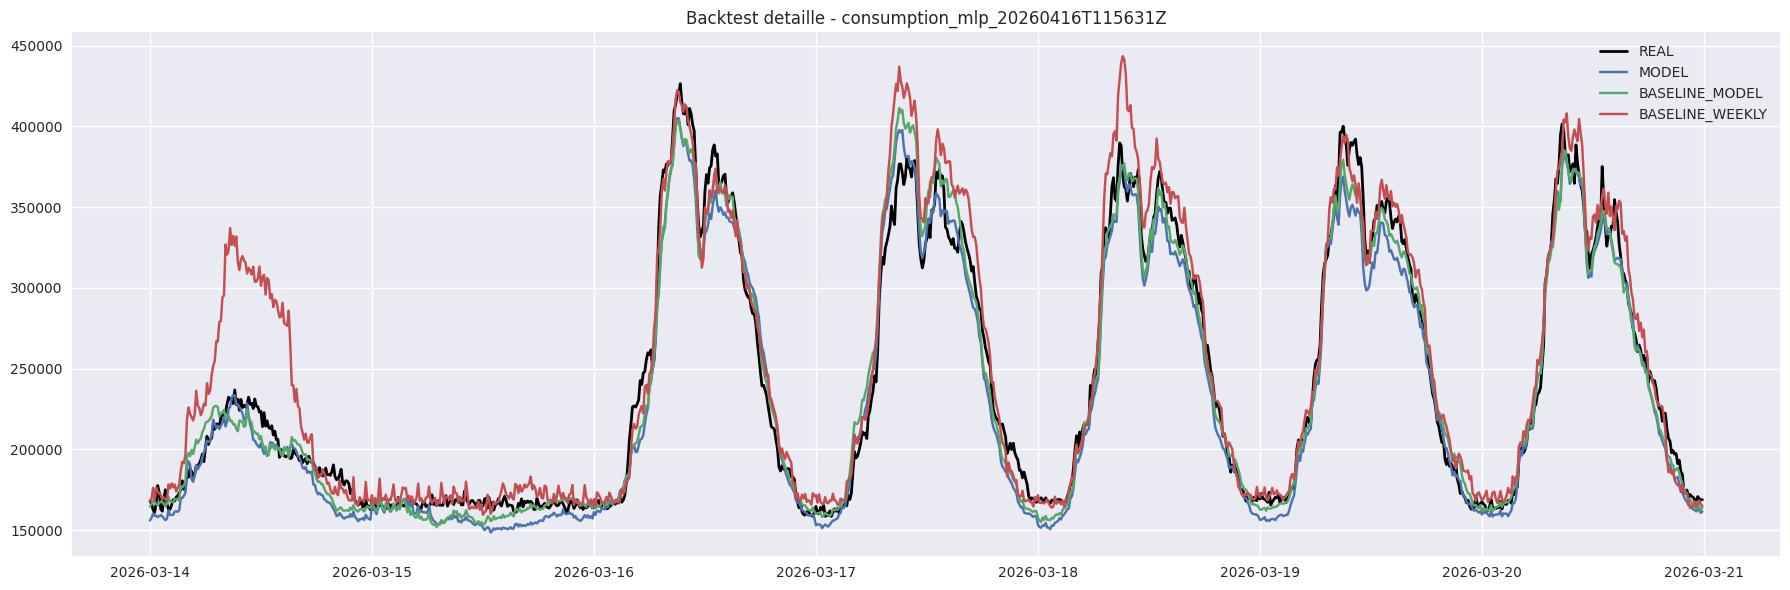

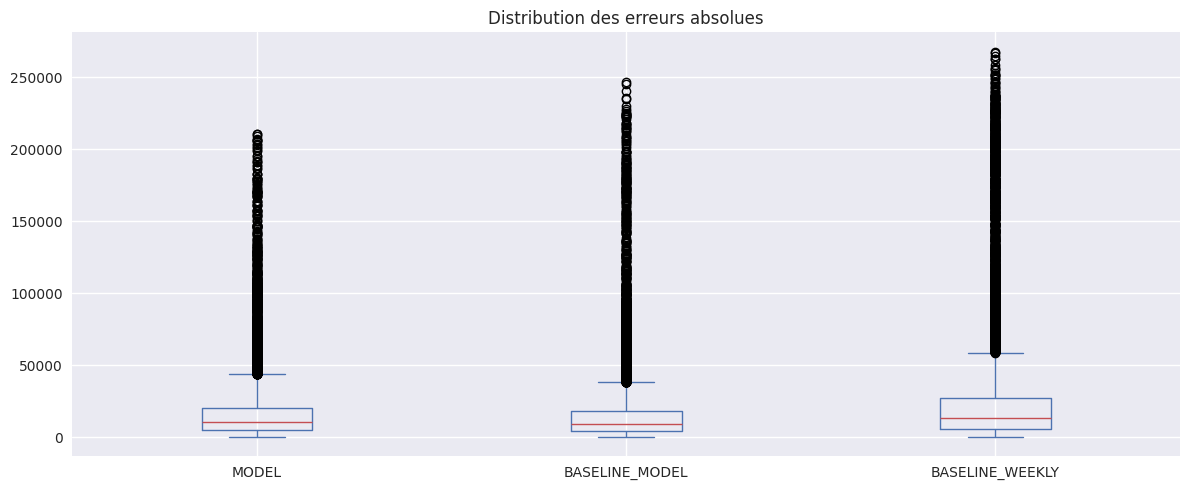

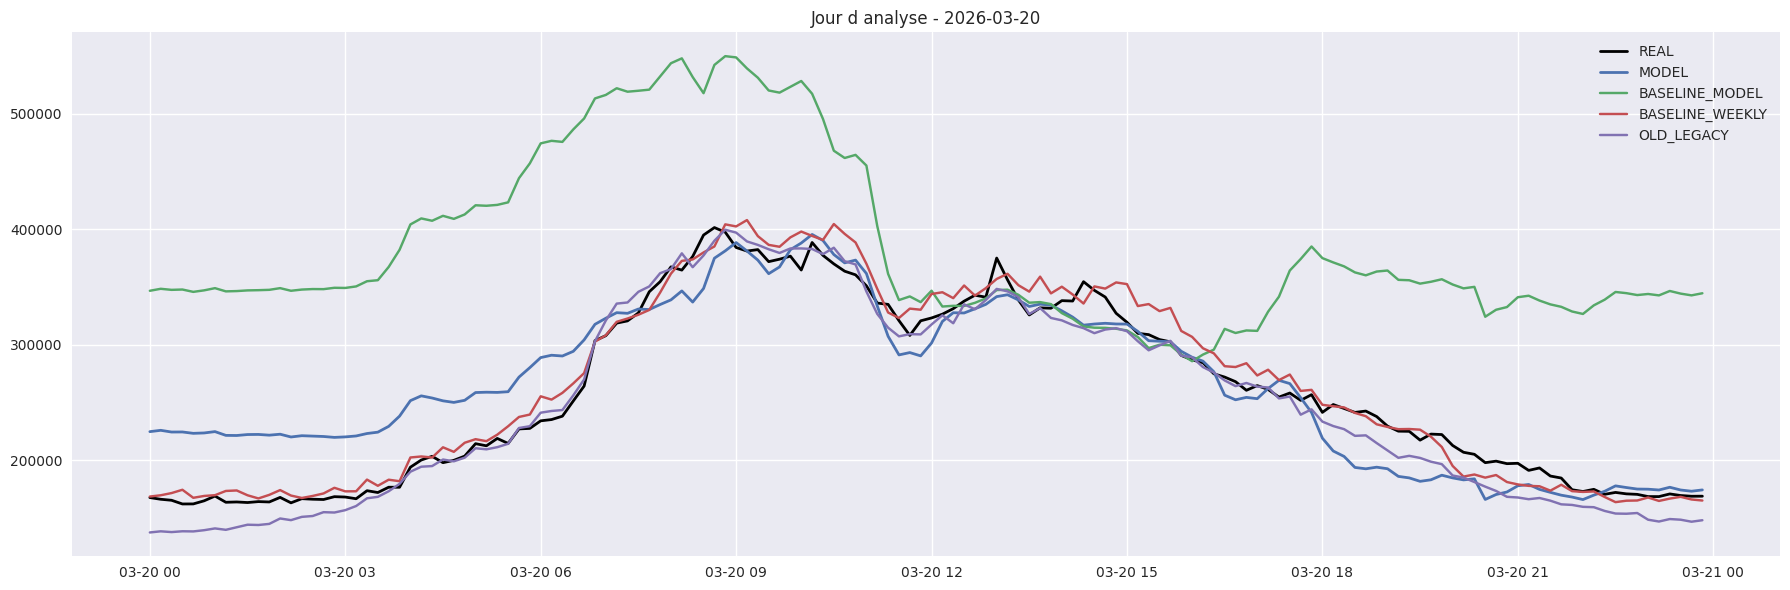

In [22]:
if not backtest.empty:
    plot_backtest = backtest.copy()
    if len(plot_backtest) > PLOT_LAST_N_POINTS:
        plot_backtest = plot_backtest.iloc[-PLOT_LAST_N_POINTS:].copy()

    plt.figure(figsize=(18, 6))
    plt.plot(plot_backtest['Date'], plot_backtest['REAL'], label='REAL', color='black', linewidth=2)
    plt.plot(plot_backtest['Date'], plot_backtest['MODEL'], label='MODEL')
    if 'BASELINE_MODEL' in plot_backtest.columns:
        plt.plot(plot_backtest['Date'], plot_backtest['BASELINE_MODEL'], label='BASELINE_MODEL')
    if 'BASELINE_WEEKLY' in plot_backtest.columns:
        plt.plot(plot_backtest['Date'], plot_backtest['BASELINE_WEEKLY'], label='BASELINE_WEEKLY')
    if 'OLD_LEGACY' in plot_backtest.columns:
        plt.plot(plot_backtest['Date'], plot_backtest['OLD_LEGACY'], label='OLD_LEGACY')
    plt.title(f'Backtest detaille - {DETAILED_RUN_ID_RESOLVED}')
    plt.legend()
    plt.tight_layout()
    plt.show()

    err_df = pd.DataFrame({'MODEL': (backtest['MODEL'] - backtest['REAL']).abs()})
    if 'BASELINE_MODEL' in backtest.columns:
        err_df['BASELINE_MODEL'] = (backtest['BASELINE_MODEL'] - backtest['REAL']).abs()
    if 'BASELINE_WEEKLY' in backtest.columns:
        err_df['BASELINE_WEEKLY'] = (backtest['BASELINE_WEEKLY'] - backtest['REAL']).abs()
    if 'OLD_LEGACY' in backtest.columns:
        err_df['OLD_LEGACY'] = (backtest['OLD_LEGACY'] - backtest['REAL']).abs()
    err_df.plot(kind='box', figsize=(12, 5), title='Distribution des erreurs absolues')
    plt.tight_layout()
    plt.show()

if not day_df.empty:
    plt.figure(figsize=(18, 6))
    plt.plot(day_df['Date'], day_df['REAL'], label='REAL', color='black', linewidth=2)
    plt.plot(day_df['Date'], day_df['MODEL'], label='MODEL', linewidth=2)
    if 'BASELINE_MODEL' in day_df.columns:
        plt.plot(day_df['Date'], day_df['BASELINE_MODEL'], label='BASELINE_MODEL')
    if 'BASELINE_WEEKLY' in day_df.columns:
        plt.plot(day_df['Date'], day_df['BASELINE_WEEKLY'], label='BASELINE_WEEKLY')
    if 'OLD_LEGACY' in day_df.columns:
        plt.plot(day_df['Date'], day_df['OLD_LEGACY'], label='OLD_LEGACY')
    plt.title(f'Jour d analyse - {RUN_SUMMARY.get("selected_analysis_day")}')
    plt.legend()
    plt.tight_layout()
    plt.show()


## 6. Replay multi-jours et comparaison des modeles


,replay_label,feature_signature,arch_label,run_id,effective_model_run_ids,fallback_used,MAE,RMSE,Bias(ME),MAPE%,SMAPE%,InTolerance%,P95AbsError,P99AbsError,UnderShare%,OverShare%,Under_MAE,Over_MAE,CorrAbsErr_vs_Real,RampingError_RMSE,MAE_skill_vs_baseline_%,RMSE_skill_vs_baseline_%,MAPE%_skill_vs_baseline_%,SMAPE%_skill_vs_baseline_%,RampingError_RMSE_skill_vs_baseline_%,InTolerance_delta_vs_baseline
0,mlp_strict_day_ahead_weather_basic | cal | tem...,cal | temp | lags | weather=basic | J=7-1-2-3-...,"MLP [1024, 512, 512]",consumption_mlp_20260416T115631Z,consumption_mlp_20260416T115631Z,False,"26,380.503581","33,429.972551","7,350.578668",12.527521,11.656096,15.277778,"58,137.350000","61,393.246406",44.444444,55.555556,"21,408.665527","30,357.974023",-0.514839,"8,618.268745",79.584054,77.388545,79.064704,72.387808,20.095356,7.638889
1,mlp_strict_day_ahead_cyclical_weather_shifted_...,cal | temp | lags | cyc | lagagg | weather=bas...,"MLP [1024, 512, 512]",consumption_mlp_20260416T115937Z,consumption_mlp_20260416T115937Z,False,"33,892.494792","40,998.561158","12,631.760417",15.277675,13.888382,11.111111,"67,334.735156","88,544.920000",49.305556,50.694444,"21,560.181338","45,886.936644",-0.238099,"8,700.267689",73.770502,72.269283,74.468799,67.099733,19.335099,3.472222
2,mlp_strict_day_ahead_baseline | cal | temp | l...,cal | temp | lags | J=7-1-2-3-4-5-6,"MLP [1024, 512, 512]",consumption_mlp_20260416T115420Z,consumption_mlp_20260416T115420Z,False,"129,215.188585","147,845.297916","126,216.455946",59.839234,42.213586,7.638889,"213,259.173437","239,123.818125",11.805556,88.194444,"12,700.514706","144,811.640994",-0.531575,"10,785.691878",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,mlp_strict_day_ahead_cyclical_weather_basic | ...,cal | temp | lags | cyc | weather=basic | J=7-...,"MLP [1024, 512, 512]",consumption_mlp_20260416T115812Z,consumption_mlp_20260416T115812Z,False,"267,753.770616","332,088.845606","264,694.454644",126.056776,64.606651,6.944444,"590,783.650000","671,211.471250",10.416667,89.583333,"14,684.716667","297,180.404797",-0.506838,"21,935.990902",-107.215401,-124.619146,-110.659074,-53.047058,-103.380471,-0.694444


,model,count,MAE,RMSE,Bias(ME),MAPE%,SMAPE%,InTolerance%,P95AbsError,P99AbsError,UnderShare%,OverShare%,Under_MAE,Over_MAE,CorrAbsErr_vs_Real,RampingError_RMSE
0,BASELINE_WEEKLY,144,"10,656.583333","13,434.021848","5,871.500000",4.058667,4.003975,28.472222,"26,811.550000","33,199.080000",30.555556,69.444444,"7,830.136364","11,900.220000",0.431523,"8,726.929128"
1,OLD_LEGACY,144,"12,904.000000","15,791.356813","-9,464.916667",5.876828,6.168865,26.388889,"27,727.050000","34,128.740000",75.000000,25.000000,"14,912.611111","6,878.166667",-0.312381,"7,246.870166"
2,mlp_strict_day_ahead_weather_basic | cal | tem...,144,"26,380.503581","33,429.972551","7,350.578668",12.527521,11.656096,15.277778,"58,137.350000","61,393.246406",44.444444,55.555556,"21,408.665527","30,357.974023",-0.514839,"8,618.268745"
3,mlp_strict_day_ahead_cyclical_weather_shifted_...,144,"33,892.494792","40,998.561158","12,631.760417",15.277675,13.888382,11.111111,"67,334.735156","88,544.920000",49.305556,50.694444,"21,560.181338","45,886.936644",-0.238099,"8,700.267689"
4,mlp_strict_day_ahead_baseline | cal | temp | l...,144,"129,215.188585","147,845.297916","126,216.455946",59.839234,42.213586,7.638889,"213,259.173437","239,123.818125",11.805556,88.194444,"12,700.514706","144,811.640994",-0.531575,"10,785.691878"
5,mlp_strict_day_ahead_cyclical_weather_basic | ...,144,"267,753.770616","332,088.845606","264,694.454644",126.056776,64.606651,6.944444,"590,783.650000","671,211.471250",10.416667,89.583333,"14,684.716667","297,180.404797",-0.506838,"21,935.990902"


,vs,reference,MAE_skill_%,RMSE_skill_%,MAPE_delta,SMAPE_delta,InTolerance_delta,Ramping_delta
0,BASELINE_WEEKLY,mlp_strict_day_ahead_baseline | cal | temp | l...,91.752840,90.913460,-55.780567,-38.209611,20.833333,"-2,058.762750"
1,OLD_LEGACY,mlp_strict_day_ahead_baseline | cal | temp | l...,90.013558,89.319000,-53.962406,-36.044721,18.750000,"-3,538.821711"
2,mlp_strict_day_ahead_weather_basic | cal | tem...,mlp_strict_day_ahead_baseline | cal | temp | l...,79.584054,77.388545,-47.311713,-30.557490,7.638889,"-2,167.423133"
3,mlp_strict_day_ahead_cyclical_weather_shifted_...,mlp_strict_day_ahead_baseline | cal | temp | l...,73.770502,72.269283,-44.561559,-28.325204,3.472222,"-2,085.424189"
4,mlp_strict_day_ahead_cyclical_weather_basic | ...,mlp_strict_day_ahead_baseline | cal | temp | l...,-107.215401,-124.619146,66.217542,22.393065,-0.694444,"11,150.299024"


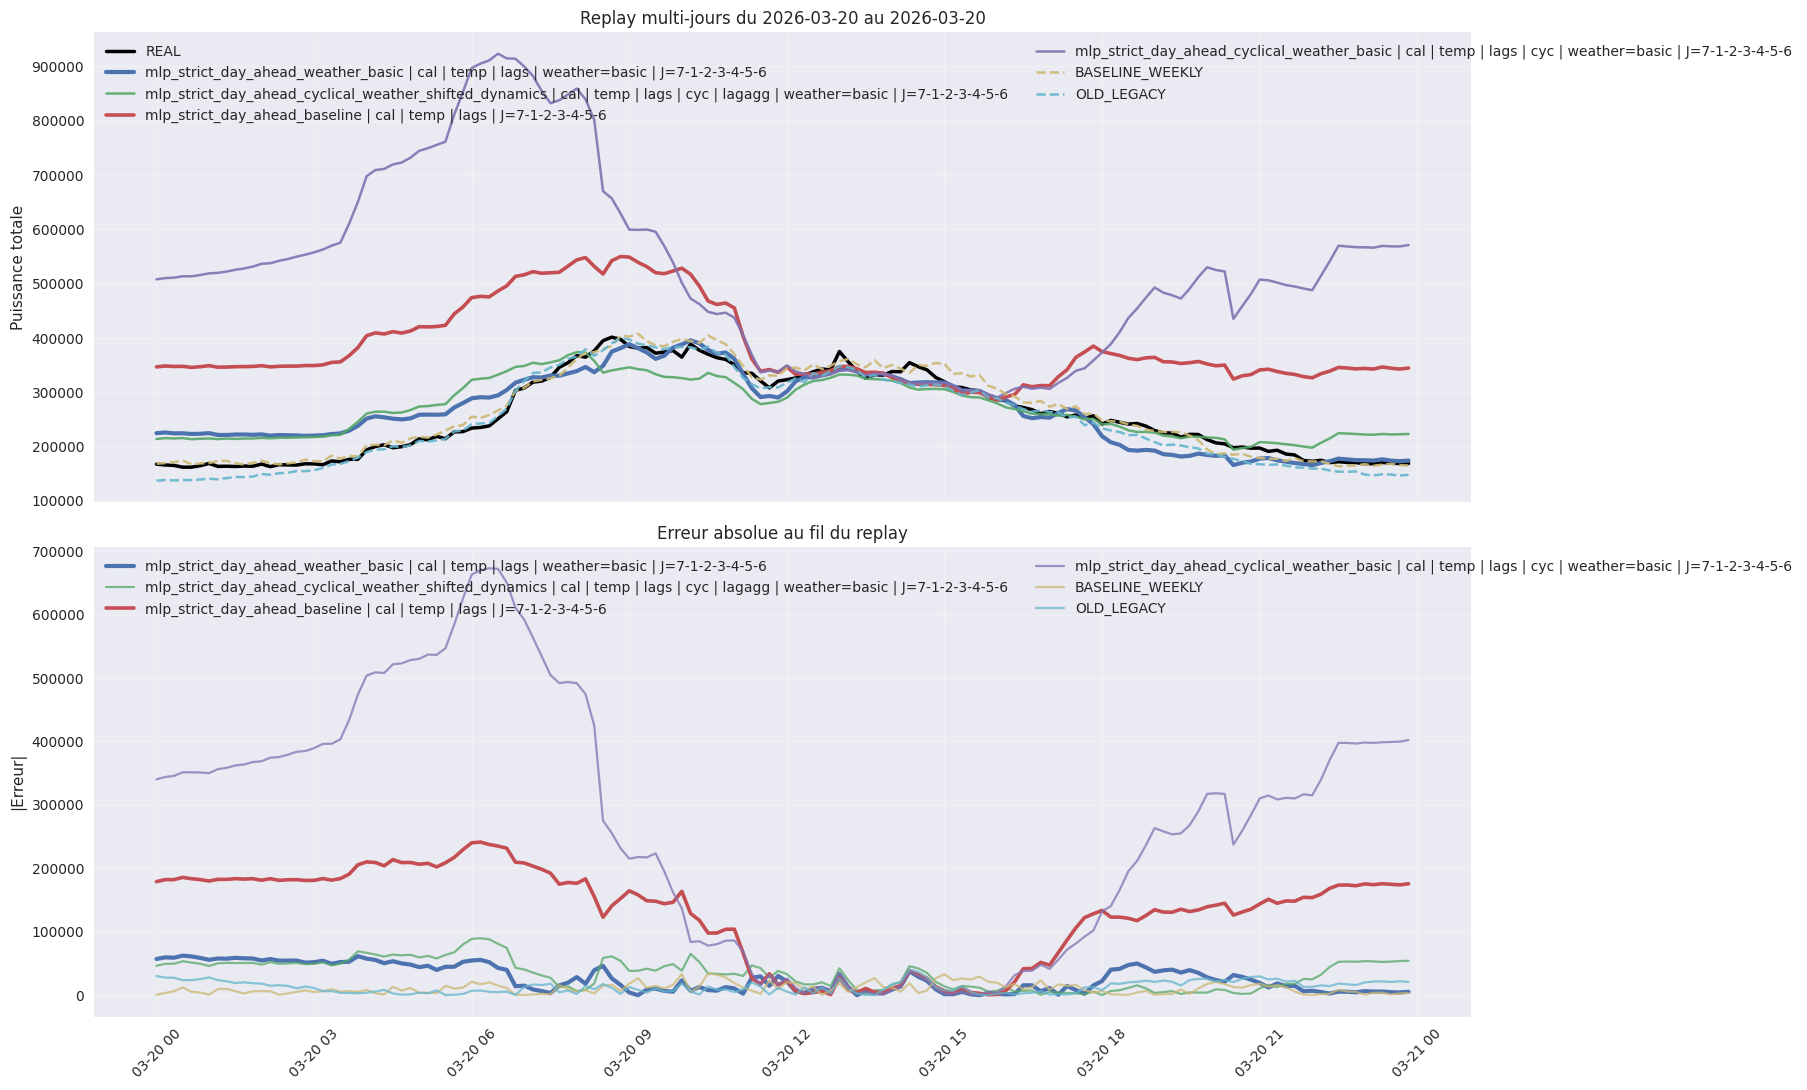

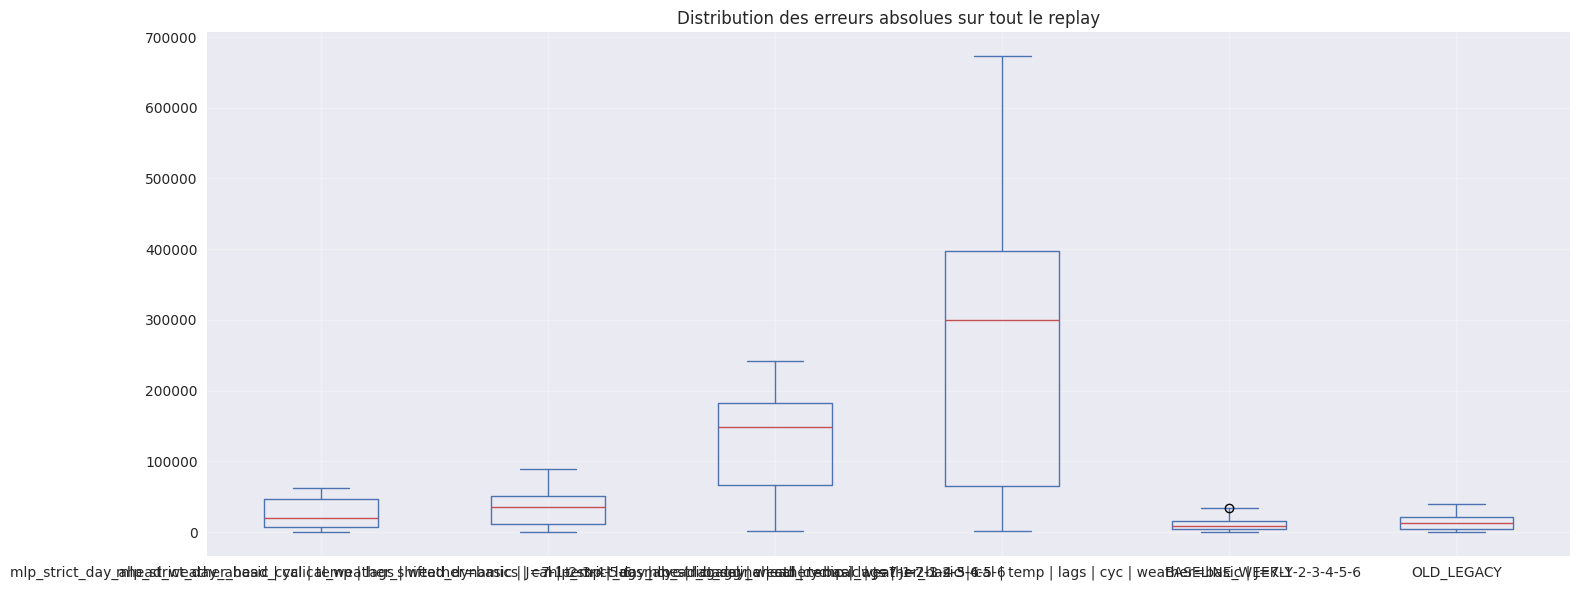

,model,count,MAE,RMSE,Bias(ME),MAPE%,SMAPE%,InTolerance%,P95AbsError,P99AbsError,UnderShare%,OverShare%,Under_MAE,Over_MAE,CorrAbsErr_vs_Real,RampingError_RMSE
0,BASELINE_WEEKLY,144,"10,656.583333","13,434.021848","5,871.500000",4.058667,4.003975,28.472222,"26,811.550000","33,199.080000",30.555556,69.444444,"7,830.136364","11,900.220000",0.431523,"8,726.929128"
1,OLD_LEGACY,144,"12,904.000000","15,791.356813","-9,464.916667",5.876828,6.168865,26.388889,"27,727.050000","34,128.740000",75.000000,25.000000,"14,912.611111","6,878.166667",-0.312381,"7,246.870166"
2,mlp_strict_day_ahead_weather_basic | cal | tem...,144,"26,380.503581","33,429.972551","7,350.578668",12.527521,11.656096,15.277778,"58,137.350000","61,393.246406",44.444444,55.555556,"21,408.665527","30,357.974023",-0.514839,"8,618.268745"
3,mlp_strict_day_ahead_cyclical_weather_shifted_...,144,"33,892.494792","40,998.561158","12,631.760417",15.277675,13.888382,11.111111,"67,334.735156","88,544.920000",49.305556,50.694444,"21,560.181338","45,886.936644",-0.238099,"8,700.267689"
4,mlp_strict_day_ahead_baseline | cal | temp | l...,144,"129,215.188585","147,845.297916","126,216.455946",59.839234,42.213586,7.638889,"213,259.173437","239,123.818125",11.805556,88.194444,"12,700.514706","144,811.640994",-0.531575,"10,785.691878"
5,mlp_strict_day_ahead_cyclical_weather_basic | ...,144,"267,753.770616","332,088.845606","264,694.454644",126.056776,64.606651,6.944444,"590,783.650000","671,211.471250",10.416667,89.583333,"14,684.716667","297,180.404797",-0.506838,"21,935.990902"


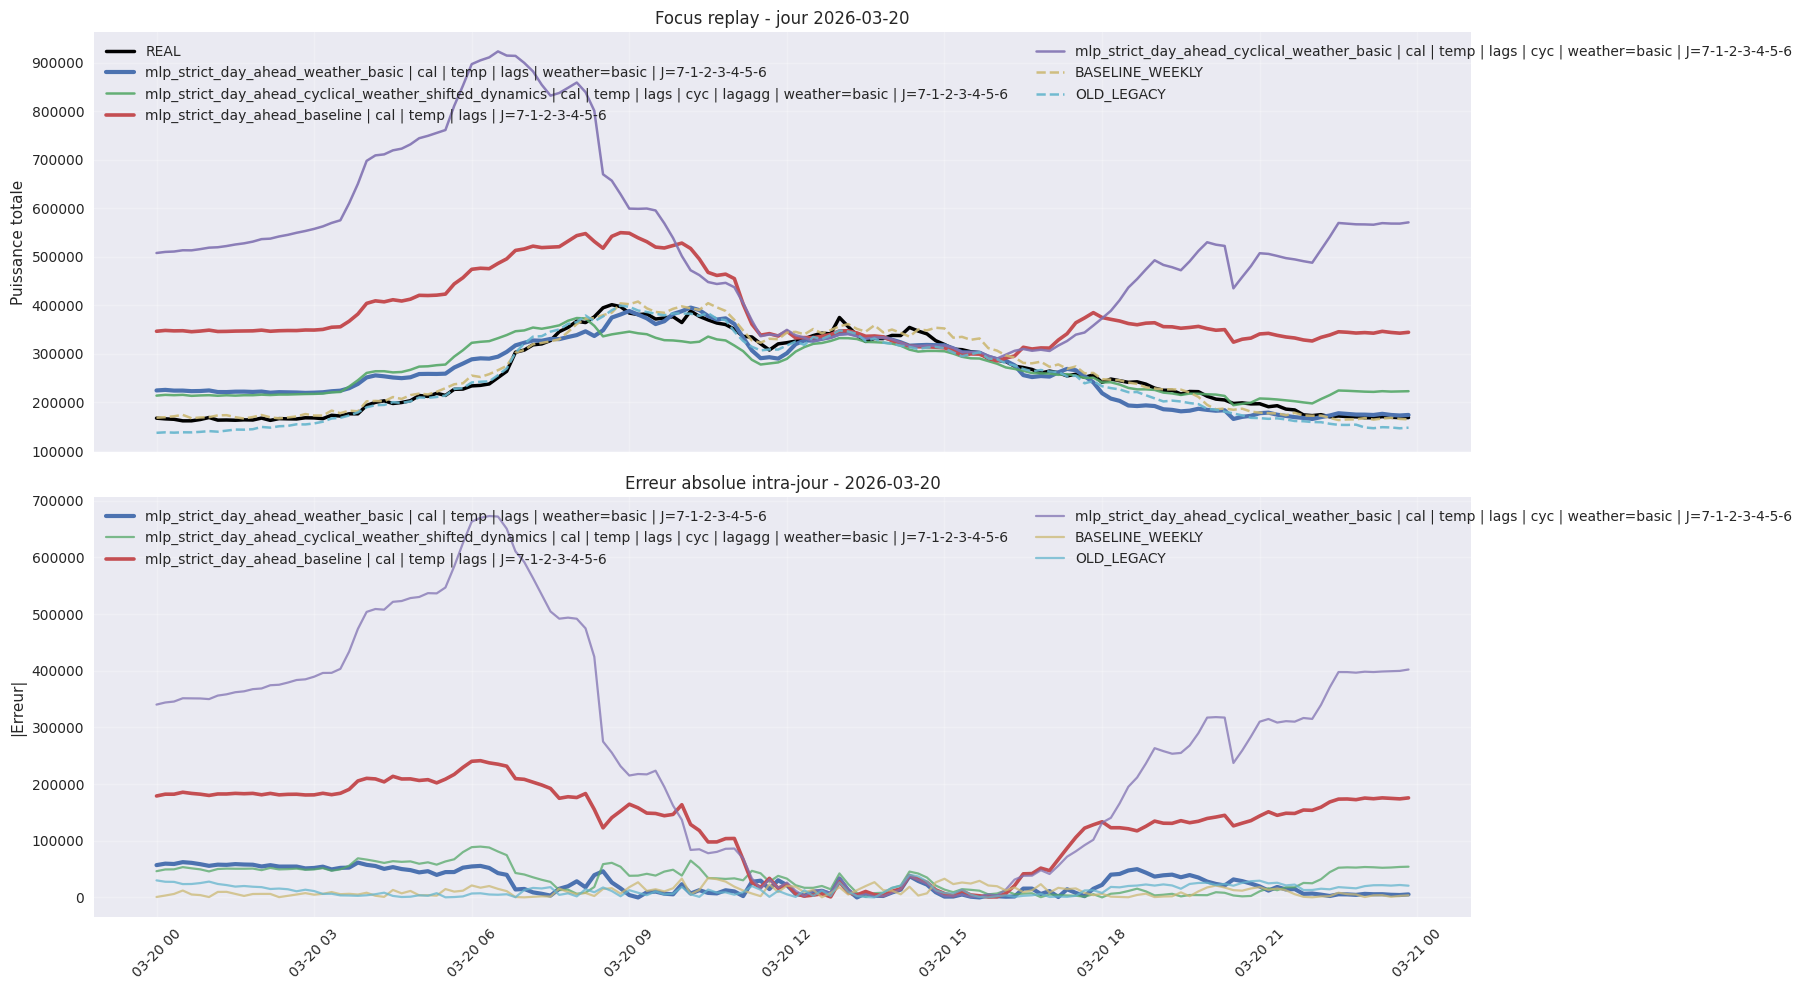

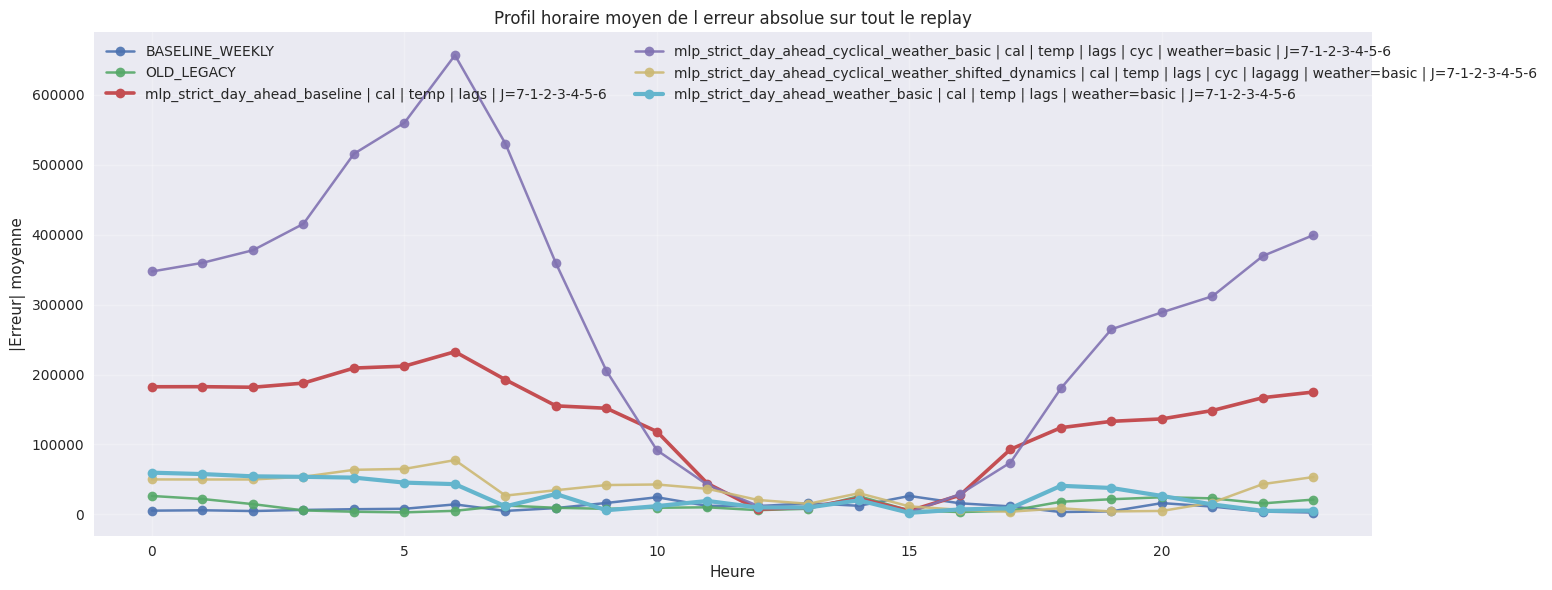

In [23]:
if REPLAY_SUMMARY_DF.empty:
    print('Aucun replay charge. Active RUN_REPLAY_BENCHMARK pour lancer un vrai replay multi-jours.')
else:
    from IPython.display import display
    from smartgrid.data.loaders import load_old_benchmark

    replay_summary_df = REPLAY_SUMMARY_DF.copy()
    replay_all_df = REPLAY_ALL_DF.copy()
    replay_per_day_df = REPLAY_PER_DAY_DF.copy()

    def build_short_replay_labels(df: pd.DataFrame, run_id_col: str = 'run_id') -> pd.DataFrame:
        out = df.copy()
        if out.empty:
            return out
        base_series = None
        for candidate in ['config_stem', 'short_name', 'config_name', 'display_name', 'model_label']:
            if candidate in out.columns:
                base_series = out[candidate].astype(str)
                break
        if base_series is None:
            base_series = out[run_id_col].astype(str)
        if 'config_name' in out.columns:
            config_mask = out['config_name'].notna()
            base_series = base_series.where(~config_mask, out['config_name'].map(lambda value: Path(str(value)).stem if pd.notna(value) else value))
        counts = base_series.groupby(base_series).transform('size')
        suffix = out[run_id_col].astype(str).str.replace('consumption_mlp_', '', regex=False).str[-8:]
        out['replay_label'] = np.where(counts > 1, base_series + ' [' + suffix + ']', base_series)
        return out

    def style_axis(ax, title: str, ylabel: str | None = None, rotation: int = 0) -> None:
        ax.set_title(title)
        if ylabel:
            ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.25)
        ax.tick_params(axis='x', rotation=rotation)

    replay_summary_df = build_short_replay_labels(replay_summary_df, run_id_col='run_id')
    replay_summary_df['run_id'] = replay_summary_df['run_id'].astype(str)

    requested_run_ids = [str(run_id) for run_id in (REPLAY_MODEL_IDS_RESOLVED or replay_summary_df['run_id'].tolist())]
    if requested_run_ids:
        replay_summary_df = replay_summary_df[replay_summary_df['run_id'].isin(requested_run_ids)].copy()

    if not replay_all_df.empty and 'requested_model_run_id' in replay_all_df.columns:
        replay_all_df['requested_model_run_id'] = replay_all_df['requested_model_run_id'].astype(str)
        replay_all_df = replay_all_df[replay_all_df['requested_model_run_id'].isin(replay_summary_df['run_id'])].copy()
        replay_all_df = replay_all_df.merge(
            replay_summary_df[['run_id', 'replay_label']].drop_duplicates(),
            left_on='requested_model_run_id',
            right_on='run_id',
            how='left',
        ).drop(columns=['run_id'], errors='ignore')

    if not replay_per_day_df.empty and 'requested_model_run_id' in replay_per_day_df.columns:
        replay_per_day_df['requested_model_run_id'] = replay_per_day_df['requested_model_run_id'].astype(str)
        replay_per_day_df = replay_per_day_df[replay_per_day_df['requested_model_run_id'].isin(replay_summary_df['run_id'])].copy()
        replay_per_day_df = replay_per_day_df.merge(
            replay_summary_df[['run_id', 'replay_label']].drop_duplicates(),
            left_on='requested_model_run_id',
            right_on='run_id',
            how='left',
        ).drop(columns=['run_id'], errors='ignore')
        replay_per_day_df['target_date'] = pd.to_datetime(replay_per_day_df['target_date'], errors='coerce').dt.date.astype(str)

    metric_sort = REPLAY_SORT_METRIC if REPLAY_SORT_METRIC in replay_summary_df.columns else ('RMSE' if 'RMSE' in replay_summary_df.columns else 'MAE')
    replay_summary_df = replay_summary_df.sort_values(metric_sort, ascending=True).reset_index(drop=True)

    baseline_row = replay_summary_df[replay_summary_df['run_id'] == str(BASELINE_RUN_ID_RESOLVED)] if BASELINE_RUN_ID_RESOLVED else pd.DataFrame()
    baseline_label = baseline_row.iloc[0]['replay_label'] if not baseline_row.empty else None
    champion_run_id = str(replay_summary_df.iloc[0]['run_id']) if not replay_summary_df.empty else None
    focus_run_id = str(DETAILED_RUN_ID_RESOLVED or REPLAY_WINNER_RUN_ID_RESOLVED or CURRENT_RUN_ID_AFTER or champion_run_id) if (DETAILED_RUN_ID_RESOLVED or REPLAY_WINNER_RUN_ID_RESOLVED or CURRENT_RUN_ID_AFTER or champion_run_id) else None
    focus_label = None
    if focus_run_id and focus_run_id in replay_summary_df['run_id'].tolist():
        focus_label = replay_summary_df.loc[replay_summary_df['run_id'] == focus_run_id, 'replay_label'].iloc[0]
    elif champion_run_id:
        focus_run_id = champion_run_id
        focus_label = replay_summary_df.loc[replay_summary_df['run_id'] == champion_run_id, 'replay_label'].iloc[0]

    if replay_all_df.empty:
        print('Les payloads de replay sont vides.')
    else:
        replay_all_df['Date'] = pd.to_datetime(replay_all_df['Date'], errors='coerce')
        replay_all_df['target_date'] = pd.to_datetime(replay_all_df['target_date'], errors='coerce').dt.date.astype(str)
        replay_all_df = replay_all_df.dropna(subset=['Date']).sort_values(['Date', 'replay_label']).reset_index(drop=True)

        real_df = replay_all_df[['Date', 'Ptot_TOTAL_Real']].dropna().drop_duplicates(subset=['Date']).rename(columns={'Ptot_TOTAL_Real': 'REAL'})
        forecast_wide_df = replay_all_df.pivot_table(
            index='Date',
            columns='replay_label',
            values='Ptot_TOTAL_Forecast',
            aggfunc='last',
        ).reset_index()
        replay_period_df = real_df.merge(forecast_wide_df, on='Date', how='outer').sort_values('Date').reset_index(drop=True)

        if HISTORY_CSV is not None and Path(HISTORY_CSV).exists():
            history_total = load_history_total(HISTORY_CSV)
            replay_period_df['BASELINE_WEEKLY'] = compute_weekly_naive_for_dates(replay_period_df['Date'], history_total)
        else:
            history_total = None
        explicit_focus_day = ANALYSIS_FOCUS_DATE_RESOLVED
        available_replay_days = pd.to_datetime(replay_period_df['Date']).dt.date.astype(str).drop_duplicates().tolist()

        _, benchmark_csv, _, _ = resolve_notebook_data_paths(PROJECT_ROOT)
        old_legacy_df = load_old_benchmark(benchmark_csv) if benchmark_csv is not None else None
        if old_legacy_df is not None and not old_legacy_df.empty:
            old_legacy_df = old_legacy_df.rename(columns={'OldLegacy_TOTAL_Forecast': 'OLD_LEGACY'})
            replay_period_df = replay_period_df.merge(old_legacy_df[['Date', 'OLD_LEGACY']].drop_duplicates(subset=['Date']), on='Date', how='left')

        model_cols = [label for label in replay_summary_df['replay_label'].tolist() if label in replay_period_df.columns]
        reference_cols = [col for col in ['BASELINE_WEEKLY', 'OLD_LEGACY'] if col in replay_period_df.columns]
        period_compare_cols = model_cols + reference_cols

        replay_comparison_rows = []
        for col in period_compare_cols:
            row = {'model': col}
            row.update(compute_metrics(replay_period_df['REAL'], replay_period_df[col]))
            replay_comparison_rows.append(row)
        replay_comparison_df = pd.DataFrame(replay_comparison_rows)
        replay_comparison_df = replay_comparison_df.sort_values([col for col in ['RMSE', 'MAE'] if col in replay_comparison_df.columns], ascending=True).reset_index(drop=True)

        reference_name = baseline_label if baseline_label in replay_comparison_df['model'].tolist() else ('BASELINE_WEEKLY' if 'BASELINE_WEEKLY' in replay_comparison_df['model'].tolist() else None)
        replay_gains_rows = []
        if reference_name:
            ref_row = replay_comparison_df.loc[replay_comparison_df['model'] == reference_name].iloc[0]
            for _, row in replay_comparison_df.iterrows():
                if row['model'] == reference_name:
                    continue
                replay_gains_rows.append({
                    'vs': row['model'],
                    'reference': reference_name,
                    'MAE_skill_%': 100 * (1 - row['MAE'] / ref_row['MAE']) if ref_row['MAE'] else np.nan,
                    'RMSE_skill_%': 100 * (1 - row['RMSE'] / ref_row['RMSE']) if ref_row['RMSE'] else np.nan,
                    'MAPE_delta': row['MAPE%'] - ref_row['MAPE%'] if 'MAPE%' in replay_comparison_df.columns else np.nan,
                    'SMAPE_delta': row['SMAPE%'] - ref_row['SMAPE%'] if 'SMAPE%' in replay_comparison_df.columns else np.nan,
                    'InTolerance_delta': row['InTolerance%'] - ref_row['InTolerance%'] if 'InTolerance%' in replay_comparison_df.columns else np.nan,
                    'Ramping_delta': row['RampingError_RMSE'] - ref_row['RampingError_RMSE'] if 'RampingError_RMSE' in replay_comparison_df.columns else np.nan,
                })
        replay_gains_df = pd.DataFrame(replay_gains_rows)

        replay_rank_cols = [
            'replay_label', 'config_name', 'feature_signature', 'arch_label', 'n_features',
            'run_id', 'effective_model_run_ids', 'fallback_used',
            'MAE', 'RMSE', 'Bias(ME)', 'MAPE%', 'SMAPE%', 'InTolerance%',
            'P95AbsError', 'P99AbsError', 'UnderShare%', 'OverShare%',
            'Under_MAE', 'Over_MAE', 'CorrAbsErr_vs_Real', 'RampingError_RMSE',
            'MAE_skill_vs_baseline_%', 'RMSE_skill_vs_baseline_%',
            'MAPE%_skill_vs_baseline_%', 'SMAPE%_skill_vs_baseline_%',
            'RampingError_RMSE_skill_vs_baseline_%', 'InTolerance_delta_vs_baseline'
        ]
        replay_rank_cols = [col for col in replay_rank_cols if col in replay_summary_df.columns]
        display(replay_summary_df[replay_rank_cols])
        display(replay_comparison_df)
        if not replay_gains_df.empty:
            display(replay_gains_df)

        replay_err_df = replay_period_df[['Date', 'REAL'] + period_compare_cols].copy()
        for col in period_compare_cols:
            replay_err_df[f'{col}__abs_err'] = (replay_err_df[col] - replay_err_df['REAL']).abs()

        fig, axes = plt.subplots(2, 1, figsize=(18, 11), sharex=True)
        axes[0].plot(replay_period_df['Date'], replay_period_df['REAL'], label='REAL', color='black', linewidth=2.5)
        for col in model_cols:
            linewidth = 3.0 if col == focus_label else (2.6 if col == baseline_label else 1.8)
            alpha = 1.0 if col in [focus_label, baseline_label] else 0.9
            axes[0].plot(replay_period_df['Date'], replay_period_df[col], label=col, linewidth=linewidth, alpha=alpha)
        for col in reference_cols:
            axes[0].plot(replay_period_df['Date'], replay_period_df[col], label=col, linewidth=1.8, linestyle='--', alpha=0.9)
        style_axis(axes[0], f'Replay multi-jours du {REPLAY_START_DATE} au {REPLAY_END_DATE}', ylabel='Puissance totale', rotation=0)
        axes[0].legend(loc='upper left', ncol=2)

        for col in period_compare_cols:
            linewidth = 3.0 if col == focus_label else (2.6 if col == baseline_label else 1.6)
            alpha = 1.0 if col in [focus_label, baseline_label] else 0.75
            axes[1].plot(replay_period_df['Date'], replay_err_df[f'{col}__abs_err'], label=col, linewidth=linewidth, alpha=alpha)
        style_axis(axes[1], 'Erreur absolue au fil du replay', ylabel='|Erreur|', rotation=45)
        axes[1].legend(loc='upper left', ncol=2)
        plt.tight_layout()
        plt.show()

        err_box_df = replay_err_df[[f'{col}__abs_err' for col in period_compare_cols]].rename(columns={f'{col}__abs_err': col for col in period_compare_cols})
        if not err_box_df.empty:
            err_box_df.plot(kind='box', figsize=(16, 6), title='Distribution des erreurs absolues sur tout le replay')
            plt.grid(True, alpha=0.25)
            plt.tight_layout()
            plt.show()

        if explicit_focus_day and explicit_focus_day in available_replay_days:
            focus_day = explicit_focus_day
        elif not replay_per_day_df.empty:
            day_metric = 'MAE' if 'MAE' in replay_per_day_df.columns else metric_sort
            daily_metric_pivot = replay_per_day_df.pivot_table(index='target_date', columns='replay_label', values=day_metric)
            daily_rmse_pivot = replay_per_day_df.pivot_table(index='target_date', columns='replay_label', values='RMSE') if 'RMSE' in replay_per_day_df.columns else pd.DataFrame()

            fig, axes = plt.subplots(2 if not daily_rmse_pivot.empty else 1, 1, figsize=(18, 10 if not daily_rmse_pivot.empty else 5), sharex=True)
            if not isinstance(axes, np.ndarray):
                axes = np.array([axes])
            for replay_label in daily_metric_pivot.columns:
                linewidth = 3.0 if replay_label == focus_label else (2.6 if replay_label == baseline_label else 1.8)
                axes[0].plot(daily_metric_pivot.index, daily_metric_pivot[replay_label], marker='o', linewidth=linewidth, alpha=0.9, label=replay_label)
            style_axis(axes[0], 'MAE journaliere sur la plage de replay', ylabel='MAE', rotation=45)
            axes[0].legend(loc='upper left', ncol=2)

            if not daily_rmse_pivot.empty:
                for replay_label in daily_rmse_pivot.columns:
                    linewidth = 3.0 if replay_label == focus_label else (2.6 if replay_label == baseline_label else 1.8)
                    axes[1].plot(daily_rmse_pivot.index, daily_rmse_pivot[replay_label], marker='o', linewidth=linewidth, alpha=0.9, label=replay_label)
                style_axis(axes[1], 'RMSE journaliere sur la plage de replay', ylabel='RMSE', rotation=45)
                axes[1].legend(loc='upper left', ncol=2)
            plt.tight_layout()
            plt.show()

            if reference_name and reference_name in daily_metric_pivot.columns:
                metric_delta_df = daily_metric_pivot.subtract(daily_metric_pivot[reference_name], axis=0).drop(columns=[reference_name], errors='ignore')
                if not metric_delta_df.empty:
                    plt.figure(figsize=(18, 5))
                    for replay_label in metric_delta_df.columns:
                        plt.plot(metric_delta_df.index, metric_delta_df[replay_label], marker='o', linewidth=2, label=replay_label)
                    plt.axhline(0, linestyle='--', color='black')
                    plt.title(f'Ecart de MAE journaliere vs {reference_name}')
                    plt.grid(True, alpha=0.25)
                    plt.xticks(rotation=45)
                    plt.legend(loc='upper left', ncol=2)
                    plt.tight_layout()
                    plt.show()

            if focus_run_id and focus_run_id in replay_per_day_df['requested_model_run_id'].astype(str).tolist():
                focus_day = str(
                    replay_per_day_df[replay_per_day_df['requested_model_run_id'].astype(str) == focus_run_id]
                    .sort_values(day_metric, ascending=False)
                    .iloc[0]['target_date']
                )
            else:
                focus_day = str(replay_per_day_df.sort_values(day_metric, ascending=False).iloc[0]['target_date'])
        else:
            focus_day = str(pd.to_datetime(replay_period_df['Date']).dt.date.iloc[-1])

        focus_day_mask = replay_period_df['Date'].dt.date == pd.to_datetime(focus_day).date()
        replay_day_df = replay_period_df.loc[focus_day_mask, ['Date', 'REAL'] + period_compare_cols].copy().sort_values('Date')

        replay_day_metrics_rows = []
        for col in period_compare_cols:
            row = {'model': col}
            row.update(compute_metrics(replay_day_df['REAL'], replay_day_df[col]))
            replay_day_metrics_rows.append(row)
        replay_day_metrics_df = pd.DataFrame(replay_day_metrics_rows)
        replay_day_metrics_df = replay_day_metrics_df.sort_values([col for col in ['RMSE', 'MAE'] if col in replay_day_metrics_df.columns], ascending=True).reset_index(drop=True)
        display(replay_day_metrics_df)

        fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True)
        axes[0].plot(replay_day_df['Date'], replay_day_df['REAL'], label='REAL', color='black', linewidth=2.5)
        for col in model_cols:
            linewidth = 3.0 if col == focus_label else (2.6 if col == baseline_label else 1.8)
            alpha = 1.0 if col in [focus_label, baseline_label] else 0.9
            axes[0].plot(replay_day_df['Date'], replay_day_df[col], label=col, linewidth=linewidth, alpha=alpha)
        for col in reference_cols:
            axes[0].plot(replay_day_df['Date'], replay_day_df[col], label=col, linewidth=1.8, linestyle='--', alpha=0.9)
        style_axis(axes[0], f'Focus replay - jour {focus_day}', ylabel='Puissance totale', rotation=0)
        axes[0].legend(loc='upper left', ncol=2)

        for col in period_compare_cols:
            abs_err = (replay_day_df[col] - replay_day_df['REAL']).abs()
            linewidth = 3.0 if col == focus_label else (2.6 if col == baseline_label else 1.6)
            alpha = 1.0 if col in [focus_label, baseline_label] else 0.75
            axes[1].plot(replay_day_df['Date'], abs_err, label=col, linewidth=linewidth, alpha=alpha)
        style_axis(axes[1], f'Erreur absolue intra-jour - {focus_day}', ylabel='|Erreur|', rotation=45)
        axes[1].legend(loc='upper left', ncol=2)
        plt.tight_layout()
        plt.show()

        hourly_err_rows = []
        replay_hourly_df = replay_period_df[['Date', 'REAL'] + period_compare_cols].copy()
        replay_hourly_df['hour'] = replay_hourly_df['Date'].dt.hour
        for col in period_compare_cols:
            work = replay_hourly_df[['hour', 'REAL', col]].dropna().copy()
            work['abs_err'] = (work[col] - work['REAL']).abs()
            hourly_profile = work.groupby('hour', as_index=False)['abs_err'].mean()
            hourly_profile['model'] = col
            hourly_err_rows.append(hourly_profile)
        hourly_err_df = pd.concat(hourly_err_rows, ignore_index=True) if hourly_err_rows else pd.DataFrame()

        if not hourly_err_df.empty:
            plt.figure(figsize=(16, 6))
            for model_name, group in hourly_err_df.groupby('model'):
                linewidth = 3.0 if model_name == focus_label else (2.6 if model_name == baseline_label else 1.8)
                alpha = 1.0 if model_name in [focus_label, baseline_label] else 0.9
                plt.plot(group['hour'], group['abs_err'], marker='o', linewidth=linewidth, alpha=alpha, label=model_name)
            plt.title('Profil horaire moyen de l erreur absolue sur tout le replay')
            plt.xlabel('Heure')
            plt.ylabel('|Erreur| moyenne')
            plt.grid(True, alpha=0.25)
            plt.legend(loc='upper left', ncol=2)
            plt.tight_layout()
            plt.show()


## 7. Comparaison meme date entre protocoles


,protocol,target_date,run_id,effective_model_run_ids,count,MAE,RMSE,Bias(ME),MAPE%,SMAPE%,InTolerance%,P95AbsError,P99AbsError,UnderShare%,OverShare%,Under_MAE,Over_MAE,CorrAbsErr_vs_Real,RampingError_RMSE
0,benchmark_test_day,2026-03-20,consumption_mlp_20260416T115631Z,consumption_mlp_20260416T115631Z,144,"8,418.360903","11,167.369945","-6,690.922014",3.361565,3.442168,38.888889,"21,356.649000","35,822.008600",80.555556,19.444444,"9,378.175603","4,441.985714",0.250399,"7,501.442388"
1,predict_target_day,2026-03-20,consumption_mlp_20260416T115631Z,consumption_mlp_20260416T115631Z,144,"26,380.503581","33,429.972551","7,350.578668",12.527521,11.656096,15.277778,"58,137.350000","61,393.246406",44.444444,55.555556,"21,408.665527","30,357.974023",-0.514839,"8,618.268745"
2,replay_same_day,2026-03-20,consumption_mlp_20260416T115631Z,consumption_mlp_20260416T115631Z,144,"26,380.503581","33,429.972551","7,350.578668",12.527521,11.656096,15.277778,"58,137.350000","61,393.246406",44.444444,55.555556,"21,408.665527","30,357.974023",-0.514839,"8,618.268745"


,reference_protocol,compared_protocol,overlap_count,mean_abs_prediction_delta,max_abs_prediction_delta
0,benchmark_test_day,predict_target_day,144,"21,872.415820","65,128.452500"
1,benchmark_test_day,replay_same_day,144,"21,872.415820","65,128.452500"


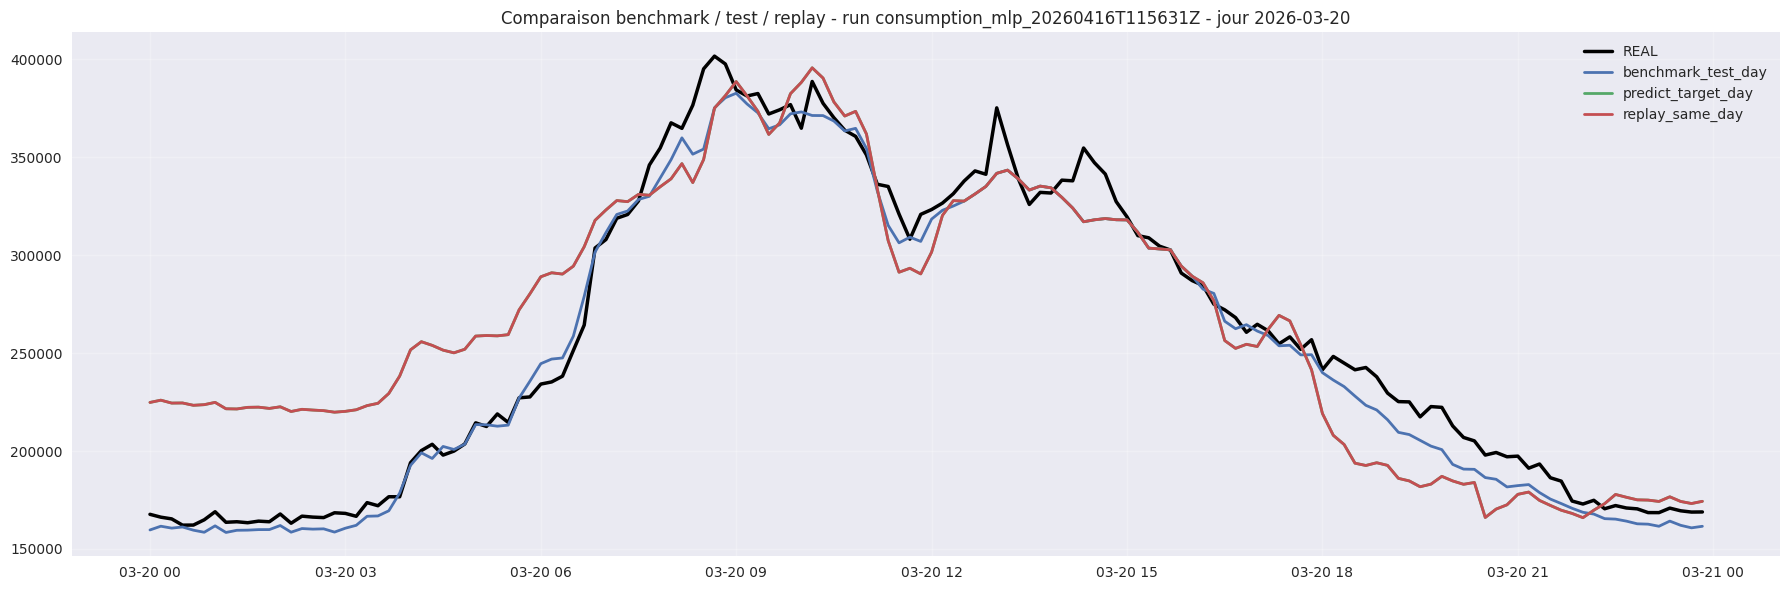

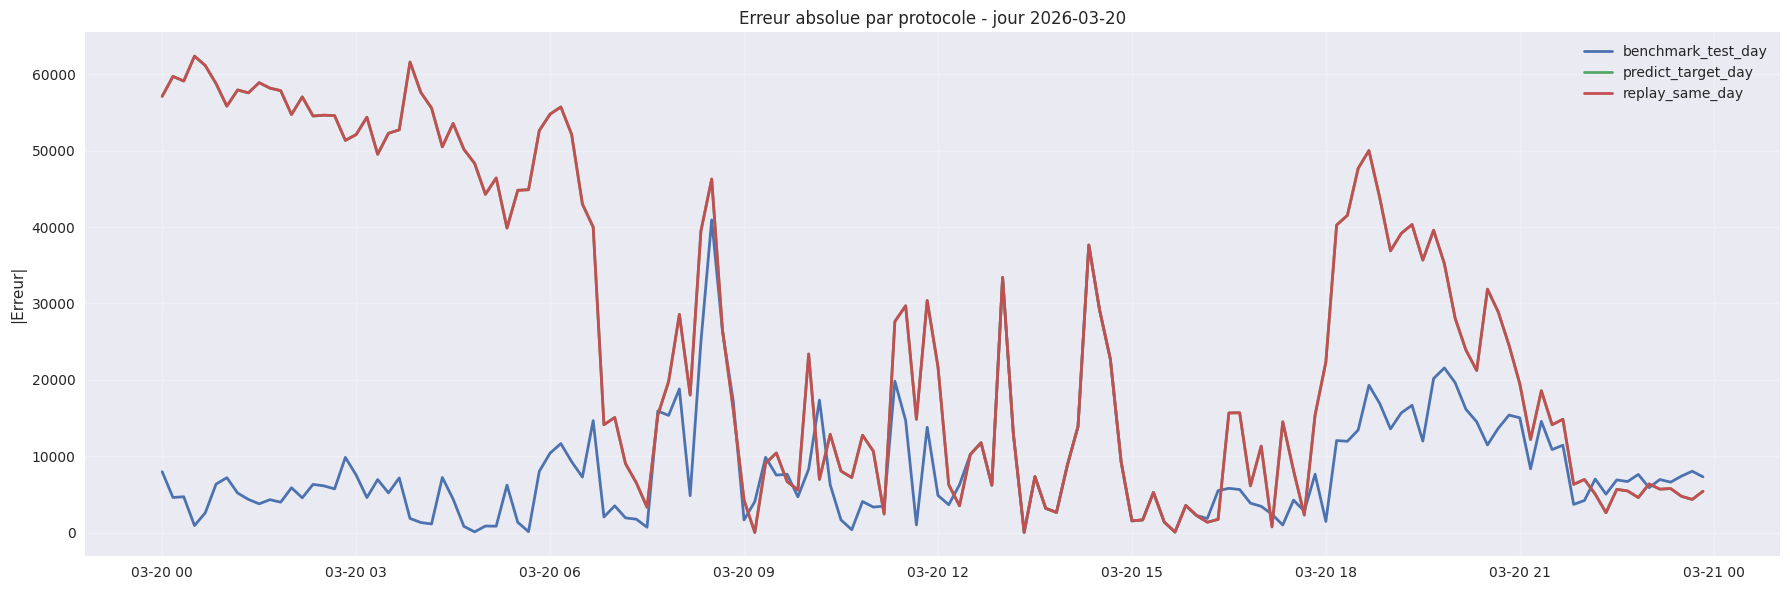

In [24]:
from IPython.display import display

PROTOCOL_COMPARISON_RUN_ID_RESOLVED = (
    str(PROTOCOL_COMPARISON_RUN_ID)
    if PROTOCOL_COMPARISON_RUN_ID
    else (
        str(DETAILED_RUN_ID_RESOLVED or REPLAY_WINNER_RUN_ID_RESOLVED or CURRENT_RUN_ID_AFTER or PROMOTED_RUN_ID_TARGET or BASELINE_RUN_ID_RESOLVED)
        if (DETAILED_RUN_ID_RESOLVED or REPLAY_WINNER_RUN_ID_RESOLVED or CURRENT_RUN_ID_AFTER or PROMOTED_RUN_ID_TARGET or BASELINE_RUN_ID_RESOLVED)
        else None
    )
)
PROTOCOL_COMPARISON_TARGET_DATE = ANALYSIS_FOCUS_DATE_RESOLVED or normalize_date_str(FORECAST_TARGET_DATE)

if not PROTOCOL_COMPARISON_TARGET_DATE:
    print('Aucun jour de focus resolu. Regle ANALYSIS_FOCUS_DATE ou la fenetre d\'analyse.')
elif not PROTOCOL_COMPARISON_RUN_ID_RESOLVED:
    print('Aucun run disponible pour la comparaison de protocoles.')
else:
    protocol_summary, protocol_backtest, _ = load_prepared_run_frames(PROJECT_ROOT, PROTOCOL_COMPARISON_RUN_ID_RESOLVED, history_csv=HISTORY_CSV, requested_day=None)
    benchmark_day_df = extract_day_from_backtest_frame(protocol_backtest, PROTOCOL_COMPARISON_TARGET_DATE, history_csv=HISTORY_CSV)
    test_day_df = build_requested_day_frame(PROJECT_ROOT, PROTOCOL_COMPARISON_RUN_ID_RESOLVED, PROTOCOL_COMPARISON_TARGET_DATE, history_csv=HISTORY_CSV)
    test_effective_model_ids = '|'.join(sorted(str(value) for value in test_day_df.get('model_run_id', pd.Series(dtype=str)).dropna().unique().tolist())) or PROTOCOL_COMPARISON_RUN_ID_RESOLVED
    replay_day_df = build_replay_requested_day_frame(PROJECT_ROOT, REPLAY_ALL_DF, PROTOCOL_COMPARISON_RUN_ID_RESOLVED, PROTOCOL_COMPARISON_TARGET_DATE, history_csv=HISTORY_CSV)

    protocol_frames = {
        'benchmark_test_day': prepare_protocol_frame(benchmark_day_df, 'benchmark_test_day', PROTOCOL_COMPARISON_TARGET_DATE, PROTOCOL_COMPARISON_RUN_ID_RESOLVED),
        'predict_target_day': prepare_protocol_frame(test_day_df, 'predict_target_day', PROTOCOL_COMPARISON_TARGET_DATE, PROTOCOL_COMPARISON_RUN_ID_RESOLVED, effective_model_run_ids=test_effective_model_ids),
        'replay_same_day': replay_day_df,
    }
    protocol_frames = {name: frame for name, frame in protocol_frames.items() if frame is not None and not frame.empty}

    if not protocol_frames:
        print(f'Aucune donnee disponible pour comparer les protocoles sur {PROTOCOL_COMPARISON_TARGET_DATE} pour le run {PROTOCOL_COMPARISON_RUN_ID_RESOLVED}.')
    else:
        protocol_metrics_df = summarize_protocol_metrics(protocol_frames)
        protocol_prediction_wide_df, protocol_delta_df = compare_protocol_predictions(protocol_frames)
        display(protocol_metrics_df)
        if not protocol_delta_df.empty:
            display(protocol_delta_df)

        merged_protocol_plot_df = None
        for protocol_name, frame in protocol_frames.items():
            work = frame[['Date', 'REAL', 'MODEL']].copy().rename(columns={'MODEL': protocol_name})
            merged_protocol_plot_df = work if merged_protocol_plot_df is None else merged_protocol_plot_df.merge(work[['Date', protocol_name]], on='Date', how='outer')
        if merged_protocol_plot_df is not None and not merged_protocol_plot_df.empty:
            merged_protocol_plot_df = merged_protocol_plot_df.sort_values('Date').reset_index(drop=True)
            plt.figure(figsize=(18, 6))
            plt.plot(merged_protocol_plot_df['Date'], merged_protocol_plot_df['REAL'], label='REAL', color='black', linewidth=2.5)
            for protocol_name in protocol_frames:
                plt.plot(merged_protocol_plot_df['Date'], merged_protocol_plot_df[protocol_name], label=protocol_name, linewidth=2)
            plt.title(f'Comparaison benchmark / test / replay - run {PROTOCOL_COMPARISON_RUN_ID_RESOLVED} - jour {PROTOCOL_COMPARISON_TARGET_DATE}')
            plt.legend()
            plt.grid(True, alpha=0.25)
            plt.tight_layout()
            plt.show()

            protocol_abs_err_df = merged_protocol_plot_df[['Date', 'REAL']].copy()
            for protocol_name in protocol_frames:
                protocol_abs_err_df[protocol_name] = (merged_protocol_plot_df[protocol_name] - merged_protocol_plot_df['REAL']).abs()
            plt.figure(figsize=(18, 6))
            for protocol_name in protocol_frames:
                plt.plot(protocol_abs_err_df['Date'], protocol_abs_err_df[protocol_name], label=protocol_name, linewidth=2)
            plt.title(f'Erreur absolue par protocole - jour {PROTOCOL_COMPARISON_TARGET_DATE}')
            plt.ylabel('|Erreur|')
            plt.grid(True, alpha=0.25)
            plt.legend()
            plt.tight_layout()
            plt.show()
